In [1]:
import pandas as pd
from pathlib import Path
import os
os.chdir("..")

In [2]:
path = Path(r'D:\Research\Project_COPD\COPD\data\raw\__2403 01_240710.xlsx')
df_ex = pd.read_excel(path, sheet_name=0, engine="openpyxl")

In [3]:
PFT_COL_MAP = {
    # PFT_2009--
    "환자번호": "Patient Number",
    "접수일자": "Implementation Date", #"Reception Date",
    "처방코드": "Prescription Code",
    "수가처방명": "Prescription Name",
    "검사실": "Laboratory",
    "실시검사실": "Implementation laboratory",
    "부위": "Region",
    "결과항목명": "Result item name",
    "결과항목결과값": "Result Value",
    "결과항목결과값 수치": "Result Numerical Value",
    "Pacs번호": "Pacs Number",

    # __2403 01_240710
    "등록번호": "Patient Number", #"Registration Number",
    "성별": "Gender",
    "생년월일": "Date of Birth",
    "내원구분": "Visit Type", #O - Outdoor patient | I - Indoor patient | E - Emergency
    "진료일자": "Treatment Date",
    "처방명": "Prescription Name",
    "처방코드": "Prescription Code",
    "처방일자": "Prescription Date",
    "시행일자": "Implementation Date",
    "결과항목": "Result item name", #"Result Item",
    "수치":  "Result Numerical Value", #"Value"
}

In [4]:
df_ex = df_ex.rename(columns=PFT_COL_MAP)

In [5]:
df_ex.columns

Index(['Patient Number', 'Gender', 'Date of Birth', 'Visit Type',
       'Treatment Date', 'Prescription Name', 'Prescription Code',
       'Prescription Date', 'Implementation Date', 'Result item name',
       'Result Numerical Value'],
      dtype='object')

In [7]:
df_t = df_ex[df_ex['Treatment Date']!=df_ex['Prescription Date']]

In [10]:
df_t.head()

,Patient Number,Gender,Date of Birth,Visit Type,Treatment Date,Prescription Name,Prescription Code,Prescription Date,Implementation Date,Result item name,Result Numerical Value
509,16031,M,19550621,I,20240527,PFT with Flow-Volume Curve(기본폐기능검사),FF6002,20240528,20240528,FVC_Pred,4.26
510,16031,M,19550621,I,20240527,PFT with Flow-Volume Curve(기본폐기능검사),FF6002,20240528,20240528,FVC_Meas,3.51
511,16031,M,19550621,I,20240527,PFT with Flow-Volume Curve(기본폐기능검사),FF6002,20240528,20240528,FVC_%Pred,82
512,16031,M,19550621,I,20240527,PFT with Flow-Volume Curve(기본폐기능검사),FF6002,20240528,20240528,FEV1_Pred,2.90
513,16031,M,19550621,I,20240527,PFT with Flow-Volume Curve(기본폐기능검사),FF6002,20240528,20240528,FEV1_Meas,2.22


In [ ]:
mapping_keys = set(PFT_COL_MAP.keys())

In [13]:
print(df_ex.dtypes)

등록번호     int64
성별      object
생년월일     int64
내원구분    object
진료일자     int64
처방명     object
처방코드    object
처방일자     int64
시행일자     int64
결과항목    object
수치      object
dtype: object


In [3]:
raw_dir = Path("data/raw")
files = sorted(raw_dir.glob("PFT*.xlsx"))
print(files)

[WindowsPath('data/raw/PFT_2009_2-1.xlsx'), WindowsPath('data/raw/PFT_2009_2-2.xlsx'), WindowsPath('data/raw/PFT_2010_2-1.xlsx'), WindowsPath('data/raw/PFT_2010_2-2.xlsx'), WindowsPath('data/raw/PFT_2011_2-1.xlsx'), WindowsPath('data/raw/PFT_2011_2-2.xlsx'), WindowsPath('data/raw/PFT_2012_2-1.xlsx'), WindowsPath('data/raw/PFT_2012_2-2.xlsx'), WindowsPath('data/raw/PFT_2013_2-1.xlsx'), WindowsPath('data/raw/PFT_2013_2-2.xlsx'), WindowsPath('data/raw/PFT_2014_2-1.xlsx'), WindowsPath('data/raw/PFT_2014_2-2.xlsx'), WindowsPath('data/raw/PFT_2015_2-1.xlsx'), WindowsPath('data/raw/PFT_2015_2-2.xlsx'), WindowsPath('data/raw/PFT_2016_2-1.xlsx'), WindowsPath('data/raw/PFT_2016_2-2.xlsx'), WindowsPath('data/raw/PFT_2017_2-1.xlsx'), WindowsPath('data/raw/PFT_2017_2-2.xlsx'), WindowsPath('data/raw/PFT_2018_2-1.xlsx'), WindowsPath('data/raw/PFT_2018_2-2.xlsx'), WindowsPath('data/raw/PFT_2019_2-1.xlsx'), WindowsPath('data/raw/PFT_2019_2-2.xlsx'), WindowsPath('data/raw/PFT_2020_2-1.xlsx'), WindowsPat

In [14]:
unique_cols = set()
for f in files:
    df = pd.read_excel(f, sheet_name=0, engine="openpyxl")
    unique_cols.update(df.columns)
    print(f"Number of Columns in {f.name}: {len(df.columns)}")
print(f"All unique columns across all files: {list(unique_cols)}")


Number of Columns in PFT_2009_2-1.xlsx: 11
Number of Columns in PFT_2009_2-2.xlsx: 11
Number of Columns in PFT_2010_2-1.xlsx: 13
Number of Columns in PFT_2010_2-2.xlsx: 13
Number of Columns in PFT_2011_2-1.xlsx: 13
Number of Columns in PFT_2011_2-2.xlsx: 13
Number of Columns in PFT_2012_2-1.xlsx: 13
Number of Columns in PFT_2012_2-2.xlsx: 13
Number of Columns in PFT_2013_2-1.xlsx: 13
Number of Columns in PFT_2013_2-2.xlsx: 13
Number of Columns in PFT_2014_2-1.xlsx: 13
Number of Columns in PFT_2014_2-2.xlsx: 13
Number of Columns in PFT_2015_2-1.xlsx: 13
Number of Columns in PFT_2015_2-2.xlsx: 13
Number of Columns in PFT_2016_2-1.xlsx: 13
Number of Columns in PFT_2016_2-2.xlsx: 13
Number of Columns in PFT_2017_2-1.xlsx: 13
Number of Columns in PFT_2017_2-2.xlsx: 13
Number of Columns in PFT_2018_2-1.xlsx: 13
Number of Columns in PFT_2018_2-2.xlsx: 13
Number of Columns in PFT_2019_2-1.xlsx: 13
Number of Columns in PFT_2019_2-2.xlsx: 13
Number of Columns in PFT_2020_2-1.xlsx: 13
Number of C

In [15]:
len(unique_cols)

13

In [ ]:
df_demo = pd.read_excel(r"D:\Research\Project_COPD\COPD\data\raw\PFT_2009_2-1.xlsx", sheet_name=0, engine="openpyxl")
    # find all unique columns

In [13]:
print(len(df_demo.columns) )

11


In [10]:
unique_col_names = []
for col in df_demo.columns:
        if col not in unique_col_names:
            unique_col_names.append(col)
print(f"Unique columns in: {list(unique_col_names)}")

Unique columns in: ['환자번호', '접수일자', '처방코드', '수가처방명', '검사실', '실시검사실', '부위', '결과항목명', '결과항목결과값', '결과항목결과값 수치', 'Pacs번호']


[]


In [ ]:
PFT_COL_MAP = {
    # PFT_2009--
    "환자번호": "Patient Number",
    "접수일자": "Reception Date",
    "처방코드": "Prescription Code",
    "수가처방명": "Prescription Name",
    "검사실": "Laboratory",
    "실시검사실": "Implementation laboratory",
    "부위": "Region",
    "결과항목명": "Result item name",
    "결과항목결과값": "Result Value",
    "결과항목결과값 수치": "Result Numerical Value",
    "Pacs번호": "Pacs Number",

    # __2403 01_240710
    "등록번호": "Registration Number",
    "성별": "Gender",
    "생년월일": "Date of Birth",
    "내원구분": "Visit Type", #O - Outdoor patient | I - Indoor patient | E - Emergency
    "진료일자": "Treatment Date",
    "처방명": "Prescription Name",
    "처방코드": "Prescription Code",
    "처방일자": "Prescription Date",
    "시행일자": "Implementation Date",
    "결과항목": "Result Item",
    "수치": "Value"
}

In [23]:
raw_dir = Path("data/raw")
files = sorted(raw_dir.glob("*.xlsx"))
if any("drug" in f.name.lower() for f in files):
    files = [f for f in files if "drug" not in f.name.lower()]
if not files:
        print(f"No files matched 'PFT*.xlsx' under {raw_dir.resolve()}")
        # return pd.DataFrame()
print(f"Total prescription files: {len(files)}")
mapping_keys = set(PFT_COL_MAP.keys())
for f in files:
    print(f.name)

__2403 01_240710.xlsx
PFT_2009_2-1.xlsx
PFT_2009_2-2.xlsx
PFT_2010_2-1.xlsx
PFT_2010_2-2.xlsx
PFT_2011_2-1.xlsx
PFT_2011_2-2.xlsx
PFT_2012_2-1.xlsx
PFT_2012_2-2.xlsx
PFT_2013_2-1.xlsx
PFT_2013_2-2.xlsx
PFT_2014_2-1.xlsx
PFT_2014_2-2.xlsx
PFT_2015_2-1.xlsx
PFT_2015_2-2.xlsx
PFT_2016_2-1.xlsx
PFT_2016_2-2.xlsx
PFT_2017_2-1.xlsx
PFT_2017_2-2.xlsx
PFT_2018_2-1.xlsx
PFT_2018_2-2.xlsx
PFT_2019_2-1.xlsx
PFT_2019_2-2.xlsx
PFT_2020_2-1.xlsx
PFT_2020_2-2.xlsx
PFT_2021_2-1.xlsx
PFT_2021_2-2.xlsx
PFT_2022_2-1.xlsx
PFT_2022_2-2.xlsx
PFT_2023_2-1.xlsx
PFT_2023_2-2.xlsx
PFT_2024_01_02.xlsx
~$__2403 01_240710.xlsx
~$PFT_2009_2-1.xlsx


In [24]:
len(files)

34

In [ ]:
def process_pft_files(
    raw_dir: str | Path = "data/raw",
    output_dir: str | Path | None = None,
    audit_csv: str | Path | None = None,
    sheet_name=0,  # first sheet by default; set to None to let pandas pick, or a string for a named sheet
) -> pd.DataFrame:
    """
    Read all 'PFT*.xlsx' in raw_dir, rename Korean columns to English using PFT_COL_MAP,
    save cleaned CSVs, and write an audit CSV listing unknown/missing columns per file.

    Returns the audit DataFrame.
    """
    raw_dir = Path(raw_dir)
    if output_dir is None:
        output_dir = raw_dir.parent / "interim" / "pft_clean"
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    if audit_csv is None:
        audit_csv = raw_dir.parent / "interim" / "pft_column_audit.csv"
    audit_csv = Path(audit_csv)
    audit_csv.parent.mkdir(parents=True, exist_ok=True)

    mapping_keys = set(PFT_COL_MAP.keys())
    audit_rows = []

    files = sorted(raw_dir.glob("*.xlsx"))
    if any("drug" in f.name.lower() for f in files):  # Exclude drug-related files
        files = [f for f in files if "drug" not in f.name.lower()]
    if not files:
        print(f"No files matched '*.xlsx' under {raw_dir.resolve()}")
        return pd.DataFrame()
    print(f"Total prescription files: {len(files)}")

    for f in files:
        try:
            df = pd.read_excel(f, sheet_name=sheet_name, engine="openpyxl")
            # If someone accidentally saved an empty sheet:
            if isinstance(df, dict):  # user chose sheet_name=None or multiple sheets
                # pick the first sheet in that case
                first_key = list(df.keys())[0]
                df = df[first_key]

            original_cols = list(df.columns)
            original_set = set(original_cols)

            # Compute audit info BEFORE renaming
            unknown_cols = sorted(original_set - mapping_keys)           # columns not in mapping
            missing_cols = sorted(mapping_keys - original_set)           # mapping keys missing in file

            # Rename
            df_renamed = df.rename(columns=PFT_COL_MAP)
            # Keep only the mapped columns
            df_renamed = df_renamed[[c for c in PFT_COL_MAP.values() if c in df_renamed.columns]]

            # Save cleaned CSV next to interim/pft_clean
            out_path = output_dir / f"{f.stem}_clean.csv"
            df_renamed.to_csv(out_path, index=False, encoding="utf-8-sig")

            audit_rows.append({
                "file": f.name,
                "rows": len(df),
                "cols": len(df.columns),
                "renamed_count": sum(c in PFT_COL_MAP for c in original_cols),
                "unknown_columns_not_in_mapping": " | ".join(map(str, unknown_cols)) if unknown_cols else "",
                "mapping_columns_missing_in_file": " | ".join(map(str, missing_cols)) if missing_cols else "",
                "saved_to": str(out_path),
                "status": "ok",
                "error": "",
            })

        except Exception as e:
            audit_rows.append({
                "file": f.name,
                "rows": "",
                "cols": "",
                "renamed_count": "",
                "unknown_columns_not_in_mapping": "",
                "mapping_columns_missing_in_file": "",
                "saved_to": "",
                "status": "error",
                "error": repr(e),
            })

    audit_df = pd.DataFrame(audit_rows)
    audit_df.to_csv(audit_csv, index=False, encoding="utf-8-sig")
    print(f"Audit saved to: {audit_csv.resolve()}")
    print(f"Cleaned files saved to: {output_dir.resolve()}")
    return audit_df

In [25]:
PFT_COL_MAP = {
    # PFT_2009--
    "환자번호": "Patient Number",
    "접수일자": "Implementation Date", #"Reception Date",
    "처방코드": "Prescription Code",
    "수가처방명": "Prescription Name",
    "검사실": "Laboratory",
    "실시검사실": "Implementation laboratory",
    "부위": "Region",
    "결과항목명": "Result item name",
    "결과항목결과값": "Result Value",
    "결과항목결과값 수치": "Result Numerical Value",
    "Pacs번호": "Pacs Number",

    # __2403 01_240710
    "등록번호": "Patient Number", #"Registration Number",
    "성별": "Gender",
    "생년월일": "Date of Birth",
    "내원구분": "Visit Type", #O - Outdoor patient | I - Indoor patient | E - Emergency
    "진료일자": "Treatment Date",
    "처방명": "Prescription Name",
    "처방코드": "Prescription Code",
    "처방일자": "Prescription Date",
    "시행일자": "Implementation Date",
    "결과항목": "Result item name", #"Result Item",
    "수치":  "Result Numerical Value", #"Value"
}

In [26]:
s = set(PFT_COL_MAP.values())

In [27]:
len(s)

16

In [ ]:
# from pathlib import Path

# from loguru import logger
# from tqdm import tqdm
# import typer

# from src.config import PROCESSED_DATA_DIR, RAW_DATA_DIR

# app = typer.Typer()


# @app.command()
# def main(
#     # ---- REPLACE DEFAULT PATHS AS APPROPRIATE ----
#     input_path: Path = RAW_DATA_DIR / "dataset.csv",
#     output_path: Path = PROCESSED_DATA_DIR / "dataset.csv",
#     # ----------------------------------------------
# ):
#     # ---- REPLACE THIS WITH YOUR OWN CODE ----
#     logger.info("Processing dataset...")
#     for i in tqdm(range(10), total=10):
#         if i == 5:
#             logger.info("Something happened for iteration 5.")
#     logger.success("Processing dataset complete.")
#     # -----------------------------------------


# if __name__ == "__main__":
#     app()

PFT_COL_MAP = {
    # PFT_2009--
    "환자번호": "Patient Number",
    "접수일자": "Prescription Date", #"Reception Date",
    "처방코드": "Prescription Code",
    "수가처방명": "Prescription Name",
    "검사실": "Laboratory",
    "실시검사실": "Implementation laboratory",
    "부위": "Region",
    "결과항목명": "Result item name",
    "결과항목결과값": "Result Value",
    "결과항목결과값 수치": "Result Numerical Value",
    "Pacs번호": "Pacs Number",

    # __2403 01_240710
    "등록번호": "Patient Number", #"Registration Number",
    "성별": "Gender",
    "생년월일": "Date of Birth",
    "내원구분": "Visit Type", #O - Outdoor patient | I - Indoor patient | E - Emergency
    "진료일자": "Treatment Date",
    "처방명": "Prescription Name",
    "처방코드": "Prescription Code",
    "처방일자": "Prescription Date",
    "시행일자": "Implementation Date",
    "결과항목": "Result item name", #"Result Item",
    "수치":  "Result Numerical Value", #"Value"
}


def rename_prescription_files(
    raw_dir: str | Path = "data/raw",
    output_dir: str | Path | None = None,
    audit_csv: str | Path | None = None,
    sheet_name=0,  # first sheet by default; set to None to let pandas pick, or a string for a named sheet
) -> pd.DataFrame:
    """
    Read all 'PFT*.xlsx' in raw_dir, rename Korean columns to English using PFT_COL_MAP,
    save cleaned CSVs, and write an audit CSV listing unknown/missing columns per file.

    Returns the audit DataFrame.
    """
    raw_dir = Path(raw_dir)
    if output_dir is None:
        output_dir = raw_dir.parent / "interim" / "pft_renamed_columns"
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    if audit_csv is None:
        audit_csv = raw_dir.parent / "interim" / "pft_renamed_columns_audit.csv"
    audit_csv = Path(audit_csv)
    audit_csv.parent.mkdir(parents=True, exist_ok=True)

    mapping_keys = set(PFT_COL_MAP.keys())
    audit_rows = []

    files = sorted(raw_dir.glob("*.xlsx"))
    if any("drug" in f.name.lower() for f in files):  # Exclude drug-related files
        files = [f for f in files if "drug" not in f.name.lower()]
    if not files:
        print(f"No files matched '*.xlsx' under {raw_dir.resolve()}")
        return pd.DataFrame()
    print(f"Total prescription files: {len(files)}")

    for f in files:
        try:
            df = pd.read_excel(f, sheet_name=sheet_name, engine="openpyxl")
            # If someone accidentally saved an empty sheet:
            if isinstance(df, dict):  # user chose sheet_name=None or multiple sheets
                # pick the first sheet in that case
                first_key = list(df.keys())[0]
                df = df[first_key]

            original_cols = list(df.columns)
            original_set = set(original_cols)

            # Compute audit info BEFORE renaming
            unknown_cols = sorted(original_set - mapping_keys)           # columns not in mapping
            missing_cols = sorted(mapping_keys - original_set)           # mapping keys missing in file

            # Rename
            df_renamed = df.rename(columns=PFT_COL_MAP)
            # Keep only the mapped columns
            df_renamed = df_renamed[[c for c in PFT_COL_MAP.values() if c in df_renamed.columns]]

            # Save cleaned CSV next to interim/pft_clean
            out_path = output_dir / f"{f.stem}_clean.csv"
            df_renamed.to_csv(out_path, index=False, encoding="utf-8-sig")

            audit_rows.append({
                "file": f.name,
                "rows": len(df),
                "cols": len(df.columns),
                "renamed_count": sum(c in PFT_COL_MAP for c in original_cols),
                "unknown_columns_not_in_mapping": " | ".join(map(str, unknown_cols)) if unknown_cols else "",
                "mapping_columns_missing_in_file": " | ".join(map(str, missing_cols)) if missing_cols else "",
                "saved_to": str(out_path),
                "status": "ok",
                "error": "",
            })

        except Exception as e:
            audit_rows.append({
                "file": f.name,
                "rows": "",
                "cols": "",
                "renamed_count": "",
                "unknown_columns_not_in_mapping": "",
                "mapping_columns_missing_in_file": "",
                "saved_to": "",
                "status": "error",
                "error": repr(e),
            })

    audit_df = pd.DataFrame(audit_rows)
    audit_df.to_csv(audit_csv, index=False, encoding="utf-8-sig")
    print(f"Audit saved to: {audit_csv.resolve()}")
    print(f"Cleaned files saved to: {output_dir.resolve()}")
    return audit_df

def process_prescription_files(
    raw_dir: str | Path = "data/raw",
    output_dir: str | Path | None = None,
    audit_csv: str | Path | None = None,
    sheet_name=0,
) -> pd.DataFrame:
    return rename_prescription_files(
        raw_dir=raw_dir,
        output_dir=output_dir,
        audit_csv=audit_csv,
        sheet_name=sheet_name,
    )   


if __name__ == "__main__":
    process_prescription_files()

In [18]:
from src.config import INTERIM_DATA_DIR

raw_dir = Path(INTERIM_DATA_DIR / "pft_renamed_columns")
files = sorted(raw_dir.glob("*.csv"))

unique_cols = set()
for f in files:
    df = pd.read_csv(f, dtype=str)
    print(f"Number of Columns in {f.name}: {len(df.columns)} | {df.columns.tolist()}")
    unique_cols.update(df.columns)
print(f"All unique columns across all files: {len(unique_cols)} | {list(unique_cols)}")

Number of Columns in __2403 01_240710_clean.csv: 16 | ['Patient Number', 'Prescription Date', 'Prescription Code', 'Prescription Name', 'Result item name', 'Result Numerical Value', 'Patient Number.1', 'Gender', 'Date of Birth', 'Visit Type', 'Treatment Date', 'Prescription Name.1', 'Prescription Date.1', 'Implementation Date', 'Result item name.1', 'Result Numerical Value.1']
Number of Columns in PFT_2009_2-1_clean.csv: 16 | ['Patient Number', 'Prescription Date', 'Prescription Code', 'Prescription Name', 'Laboratory', 'Implementation laboratory', 'Region', 'Result item name', 'Result Value', 'Result Numerical Value', 'Pacs Number', 'Patient Number.1', 'Prescription Name.1', 'Prescription Date.1', 'Result item name.1', 'Result Numerical Value.1']
Number of Columns in PFT_2009_2-2_clean.csv: 16 | ['Patient Number', 'Prescription Date', 'Prescription Code', 'Prescription Name', 'Laboratory', 'Implementation laboratory', 'Region', 'Result item name', 'Result Value', 'Result Numerical Val

In [19]:
df = pd.read_csv(files[0], dtype=str)
print(f"Number of Columns in {f.name}: {len(df.columns)} | {df.columns.tolist()}")

Number of Columns in PFT_2024_01_02_clean.csv: 16 | ['Patient Number', 'Prescription Date', 'Prescription Code', 'Prescription Name', 'Result item name', 'Result Numerical Value', 'Patient Number.1', 'Gender', 'Date of Birth', 'Visit Type', 'Treatment Date', 'Prescription Name.1', 'Prescription Date.1', 'Implementation Date', 'Result item name.1', 'Result Numerical Value.1']


In [24]:
df_old = pd.read_excel(r"D:\Research\Project_COPD\COPD\data\raw\PFT_2024_01_02.xlsx", sheet_name=0, engine="openpyxl")
print(f"Number of Columns in {files[0].name}: {len(df_old.columns)} | {df_old.columns.tolist()}")

Number of Columns in __2403 01_240710_clean.csv: 11 | ['환자번호', '접수일자', '처방코드', '수가처방명', '검사실', '실시검사실', '부위', '결과항목명', '결과항목결과값', '결과항목결과값 수치', 'Pacs번호']


In [26]:
from src.config import INTERIM_DATA_DIR

raw_dir = Path(INTERIM_DATA_DIR / "pft_renamed_columns")
files = sorted(raw_dir.glob("*.csv"))

unique_cols = set()
for f in files:
    df = pd.read_csv(f, dtype=str)
    print(f"Number of Columns in {f.name}: {len(df.columns)} | {df.columns.tolist()}")
    unique_cols.update(df.columns)
print(f"All unique columns across all files: {len(unique_cols)} | {list(unique_cols)}")

Number of Columns in __2403 01_240710_renamed.csv: 11 | ['Prescription Code', 'Patient Number', 'Gender', 'Date of Birth', 'Visit Type', 'Treatment Date', 'Prescription Name', 'Prescription Date', 'Implementation Date', 'Result item name', 'Result Numerical Value']
Number of Columns in PFT_2009_2-1_renamed.csv: 11 | ['Patient Number', 'Prescription Date', 'Prescription Code', 'Prescription Name', 'Laboratory', 'Implementation laboratory', 'Region', 'Result item name', 'Result Value', 'Result Numerical Value', 'Pacs Number']
Number of Columns in PFT_2009_2-2_renamed.csv: 11 | ['Patient Number', 'Prescription Date', 'Prescription Code', 'Prescription Name', 'Laboratory', 'Implementation laboratory', 'Region', 'Result item name', 'Result Value', 'Result Numerical Value', 'Pacs Number']
Number of Columns in PFT_2010_2-1_renamed.csv: 11 | ['Patient Number', 'Prescription Date', 'Prescription Code', 'Prescription Name', 'Laboratory', 'Implementation laboratory', 'Region', 'Result item name',

In [29]:
df_old = df = pd.read_csv(r"D:\Research\Project_COPD\COPD\data\interim\ALL_PRESCRIPTION_DATA.csv")
print(f"Number of Columns in: {len(df_old.columns)} | {df_old.columns.tolist()}")

C:\Users\Shayahn-DKE\AppData\Local\Temp\ipykernel_11496\3667792280.py:1: DtypeWarning: Columns (2,4,10,11,12,13,14) have mixed types. Specify dtype option on import or set low_memory=False.
  df_old = df = pd.read_csv(r"D:\Research\Project_COPD\COPD\data\interim\ALL_PRESCRIPTION_DATA.csv")


Number of Columns in: 16 | ['Prescription Code', 'Patient Number', 'Gender', 'Date of Birth', 'Visit Type', 'Treatment Date', 'Prescription Name', 'Prescription Date', 'Implementation Date', 'Result item name', 'Result Numerical Value', 'Laboratory', 'Implementation laboratory', 'Region', 'Result Value', 'Pacs Number']


In [32]:
for i, col in enumerate(df_old.columns):
    print(i, col, type(col))

0 Prescription Code <class 'str'>
1 Patient Number <class 'str'>
2 Gender <class 'str'>
3 Date of Birth <class 'str'>
4 Visit Type <class 'str'>
5 Treatment Date <class 'str'>
6 Prescription Name <class 'str'>
7 Prescription Date <class 'str'>
8 Implementation Date <class 'str'>
9 Result item name <class 'str'>
10 Result Numerical Value <class 'str'>
11 Laboratory <class 'str'>
12 Implementation laboratory <class 'str'>
13 Region <class 'str'>
14 Result Value <class 'str'>
15 Pacs Number <class 'str'>


In [46]:
df_old.columns

Index(['Prescription Code', 'Patient Number', 'Gender', 'Date of Birth',
       'Visit Type', 'Treatment Date', 'Prescription Name',
       'Prescription Date', 'Implementation Date', 'Result item name',
       'Result Numerical Value', 'Laboratory', 'Implementation laboratory',
       'Region', 'Result Value', 'Pacs Number'],
      dtype='object')

In [44]:
# Keep rows where: (item name != value) AND (value is not NaN)
df = df_old.copy()
df['Result Numerical Value'] = pd.to_numeric(df["Result Numerical Value"], errors="coerce")
df['Result Value'] = pd.to_numeric(df["Result Value"], errors="coerce")
df_t1 = df[
    (df['Result Numerical Value'] != df['Result Value']) &
    (df['Result Value'].notna())
]

In [45]:
df_t1[['Result Numerical Value', 'Result Value']]

,Result Numerical Value,Result Value


In [ ]:
['Prescription Code', 'Patient Number', 'Gender', 'Date of Birth',
       'Visit Type', 'Treatment Date', 'Prescription Name',
       'Prescription Date', 'Implementation Date', 'Result item name',
       'Result Numerical Value', 'Laboratory', 'Implementation laboratory',
       'Region', 'Result Value', 'Pacs Number']

In [47]:
desired_columns = ['Patient Number', 'Prescription Code', 'Prescription Name', 'Result item name', 'Treatment Date', 'Result Numerical Value']
df = df[desired_columns]

In [48]:
df.head()

,Patient Number,Prescription Code,Prescription Name,Result item name,Treatment Date,Result Numerical Value
0,5805,FE7123,Bronchodilator Test,FVC_Meas,20240329.0,2.26
1,5805,FE7123,Bronchodilator Test,FVC_%Pred,20240329.0,75.00
2,5805,FE7123,Bronchodilator Test,FVC_Post_Meas,20240329.0,2.35
3,5805,FE7123,Bronchodilator Test,FVC_Post_%Pred,20240329.0,79.00
4,5805,FE7123,Bronchodilator Test,FVC_Post_%Chg,20240329.0,4.00


In [49]:
df['Prescription Name'].unique()

array(['Bronchodilator Test', 'PFT with Flow-Volume Curve(기본폐기능검사)',
       'CO Diffusing Capacity Measurement', 'Bronchodilator Test ',
       'PFT with Flow-Volume Curve(기본폐기능검사) ',
       'CO Diffusing Capacity Measurement ', 'Plethysmography',
       'Plethysmography ', '[임상] PFT with Flow-Volume Curve(기본폐기능검사)',
       '[응급] PFT with Flow-Volume Curve(기본폐기능검사)',
       '[협진]Bronchodilator Test',
       '[협진]PFT with Flow-Volume Curve(기본폐기능검사)',
       '[협진]CO Diffusing Capacity Measurement',
       '[임상] Bronchodilator Test', 'PFT without Flow-Volume Curve[수술전검사]'],
      dtype=object)

In [59]:
df["Result item name"] = df["Result item name"].astype("string")
item_list = df['Result item name'].unique()

In [64]:
len(item_list)

189

In [21]:
item_list

<StringArray>
[                  'FVC_Meas',                  'FVC_%Pred',
              'FVC_Post_Meas',             'FVC_Post_%Pred',
              'FVC_Post_%Chg',                  'FEV1_Meas',
                 'FEV1_%Pred',             'FEV1_Post_Meas',
            'FEV1_Post_%Pred',             'FEV1_Post_%Chg',
 ...
      'CO Diffusing IVC Pred',      'CO Diffusing IVC Meas',
     'CO Diffusing IVC %Pred',       'CO Diffusing VA Pred',
       'CO Diffusing VA Meas',      'CO Diffusing VA %Pred',
  'CO Diffusing DLCO/VA Pred',  'CO Diffusing DLCO/VA Meas',
 'CO Diffusing DLCO/VA %Pred',                         <NA>]
Length: 189, dtype: string

In [61]:
desired_items = ["FVC", "FEV1", "DLCO"]

filter_items = [
    x for x in item_list
    if isinstance(x, str) and any(k in x for k in desired_items)
]
filter_items


['FVC_Meas',
 'FVC_%Pred',
 'FVC_Post_Meas',
 'FVC_Post_%Pred',
 'FVC_Post_%Chg',
 'FEV1_Meas',
 'FEV1_%Pred',
 'FEV1_Post_Meas',
 'FEV1_Post_%Pred',
 'FEV1_Post_%Chg',
 'FEV1FVC_Meas',
 'FEV1FVC_%Pred',
 'FEV1FVC_Post_Meas',
 'FEV1FVC_Post_%Pred',
 'FEV1FVC_Post_%Chg',
 'FVC_Pred',
 'FEV1_Pred',
 'FEV1/FVC_Pred',
 'FEV1/FVC_Meas',
 'FEV1/FVC_%Pred',
 'DLCO_Pred',
 'DLCO_Meas',
 'DLCO_%Pred',
 'DLCOVA_Pred',
 'DLCOVA_Meas',
 'DLCOVA_%Pred',
 'PFT FVC Pred',
 'PFT FVC Meas',
 'PFT FVC %Pred',
 'PFT FEV1 Pred',
 'PFT FEV1 Meas',
 'PFT FEV1 %Pred',
 'PFT FEV1/FVC Pred',
 'PFT FEV1/FVC Meas',
 'PFT FEV1/FVC %Pred',
 'Bronchodilator FVC Meas',
 'Bronchodilator FVC %Pred',
 'Bronchodilator FVC %Chg.',
 'Bronchodilator FEV1 Meas',
 'Bronchodilator FEV1 %Pred',
 'Bronchodilator FEV1 %Chg.',
 'Bronchodilator FEV1/FVC Meas',
 'Bronchodilator FEV1/FVC %Pred',
 'Bronchodilator FEV1/FVC %Chg.',
 'CO Diffusing DLCO Pred',
 'CO Diffusing DLCO Meas',
 'CO Diffusing DLCO %Pred',
 'CO Diffusing DLCO/VA 

In [62]:
len(filter_items)

50

In [ ]:
df["Result item name"] = df["Result item name"].astype("string")
item_list = df['Result item name'].unique()

In [31]:
for item in item_list:
    print(item)

FVC_Meas
FVC_%Pred
FVC_Post_Meas
FVC_Post_%Pred
FVC_Post_%Chg
FEV1_Meas
FEV1_%Pred
FEV1_Post_Meas
FEV1_Post_%Pred
FEV1_Post_%Chg
FEV1FVC_Meas
FEV1FVC_%Pred
FEV1FVC_Post_Meas
FEV1FVC_Post_%Pred
FEV1FVC_Post_%Chg
FEF2575_Meas
FEF2575_%Pred
FEF2575_Post_Meas
FEF2575_Post_%Pred
FEF2575_Post_%Chg
PEF_Meas
PEF_%Pred
PEF_Post_Meas
PEF_Post_%Pred
PEF_Post_%Chg
FET100_Meas
FET100_Post_Meas
FET100_Post_%Chg
FIVC_Meas
FIVC_%Pred
FIVC_Post_Meas
FIVC_Post_%Pred
FIVC_Post_%Chg
FVC_Pred
FEV1_Pred
FEV1/FVC_Pred
FEV1/FVC_Meas
FEV1/FVC_%Pred
FEF2575_Pred
PEF_Pred
FIVC_Pred
DLCO_Pred
DLCO_Meas
DLCO_%Pred
DLADJ_Pred
DLADJ_Meas
DLADJ_%Pred
VA_Meas
IVC_Pred
IVC_Meas
IVC_%Pred
TLC_Pred
TLC_Meas
TLC_%Pred
VC_Pred
VC_Meas
VC_%Pred
RV_Pred
RV_Meas
RV_%Pred
FRC_Pred
FRC_Meas
FRC_%Pred
ERV_Pred
ERV_Meas
ERV_%Pred
IC_Pred
IC_Meas
IC_%Pred
VA_Pred
VA_%Pred
DLCOVA_Pred
DLCOVA_Meas
DLCOVA_%Pred
Plethysmography FRC %Pred
Plethysmography RV/TLC Pred
Plethysmography RV/TLC Meas
Plethysmography ERV Pred
Plethysmography E

In [ ]:
s = s.strip()
    m = re.search(r'(?:Post_)?[^ _]+$', s

In [38]:
s  = "CO Diffusing DLCO/VA Pred"

In [39]:
s.strip()
s

'CO Diffusing DLCO/VA Pred'

In [40]:
pat = r'((?:Post_)?[^ _]+)$' 

In [42]:
s.str.extract(pat, expand=False)

AttributeError: type object 'str' has no attribute 'extract'

In [2]:
from src.config import RAW_DATA_DIR, INTERIM_DATA_DIR
import re


# not needed
from src.logging_config import setup_logger
logger = setup_logger(verbose=True)


2025-08-23 22:38:08.720 | INFO     | src.config:<module>:11 - PROJ_ROOT path is: D:\Research\Project_COPD\COPD


In [5]:
df.head()

,Prescription Code,Patient Number,Gender,Date of Birth,Visit Type,Treatment Date,Prescription Name,Prescription Date,Implementation Date,Result item name,Result Numerical Value,Laboratory,Implementation laboratory,Region,Result Value,Pacs Number
0,FE7123,5805,M,19350624.0,O,20240329.0,Bronchodilator Test,20240329,20240418.0,FVC_Meas,2.26,NaN,NaN,NaN,NaN,NaN
1,FE7123,5805,M,19350624.0,O,20240329.0,Bronchodilator Test,20240329,20240418.0,FVC_%Pred,75.0,NaN,NaN,NaN,NaN,NaN
2,FE7123,5805,M,19350624.0,O,20240329.0,Bronchodilator Test,20240329,20240418.0,FVC_Post_Meas,2.35,NaN,NaN,NaN,NaN,NaN
3,FE7123,5805,M,19350624.0,O,20240329.0,Bronchodilator Test,20240329,20240418.0,FVC_Post_%Pred,79.0,NaN,NaN,NaN,NaN,NaN
4,FE7123,5805,M,19350624.0,O,20240329.0,Bronchodilator Test,20240329,20240418.0,FVC_Post_%Chg,4.0,NaN,NaN,NaN,NaN,NaN


In [17]:
s = filter_items[0]
s

'FVC_Meas'

In [18]:
m = re.search(r'[^ _]+$', s)
m

<re.Match object; span=(4, 8), match='Meas'>

In [58]:
df = pd.read_csv(Path(INTERIM_DATA_DIR /"ALL_PRESCRIPTION_DATA.csv"))

C:\Users\Shayahn-DKE\AppData\Local\Temp\ipykernel_57636\1106365309.py:1: DtypeWarning: Columns (2,4,10,11,12,13,14) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(Path(INTERIM_DATA_DIR /"ALL_PRESCRIPTION_DATA.csv"))


In [28]:
logger.info(f"Number of unique patients: {df['Patient Number'].nunique()}" )

2025-08-23 20:47:59.120 | INFO     | __main__:<module>:1 - Number of unique patients: 31612


In [59]:
df["Result item name"] = df["Result item name"].astype("string")
item_list = df['Result item name'].unique()

In [60]:
len(item_list)

189

In [63]:
df.columns

Index(['Prescription Code', 'Patient Number', 'Gender', 'Date of Birth',
       'Visit Type', 'Treatment Date', 'Prescription Name',
       'Prescription Date', 'Implementation Date', 'Result item name',
       'Result Numerical Value', 'Laboratory', 'Implementation laboratory',
       'Region', 'Result Value', 'Pacs Number'],
      dtype='object')

In [64]:
df.head()

,Prescription Code,Patient Number,Gender,Date of Birth,Visit Type,Treatment Date,Prescription Name,Prescription Date,Implementation Date,Result item name,Result Numerical Value,Laboratory,Implementation laboratory,Region,Result Value,Pacs Number
0,FE7123,5805,M,19350624.0,O,20240329.0,Bronchodilator Test,20240329,20240418.0,FVC_Meas,2.26,NaN,NaN,NaN,NaN,NaN
1,FE7123,5805,M,19350624.0,O,20240329.0,Bronchodilator Test,20240329,20240418.0,FVC_%Pred,75.0,NaN,NaN,NaN,NaN,NaN
2,FE7123,5805,M,19350624.0,O,20240329.0,Bronchodilator Test,20240329,20240418.0,FVC_Post_Meas,2.35,NaN,NaN,NaN,NaN,NaN
3,FE7123,5805,M,19350624.0,O,20240329.0,Bronchodilator Test,20240329,20240418.0,FVC_Post_%Pred,79.0,NaN,NaN,NaN,NaN,NaN
4,FE7123,5805,M,19350624.0,O,20240329.0,Bronchodilator Test,20240329,20240418.0,FVC_Post_%Chg,4.0,NaN,NaN,NaN,NaN,NaN


In [62]:
for item in item_list:
    print(item)

FVC_Meas
FVC_%Pred
FVC_Post_Meas
FVC_Post_%Pred
FVC_Post_%Chg
FEV1_Meas
FEV1_%Pred
FEV1_Post_Meas
FEV1_Post_%Pred
FEV1_Post_%Chg
FEV1FVC_Meas
FEV1FVC_%Pred
FEV1FVC_Post_Meas
FEV1FVC_Post_%Pred
FEV1FVC_Post_%Chg
FEF2575_Meas
FEF2575_%Pred
FEF2575_Post_Meas
FEF2575_Post_%Pred
FEF2575_Post_%Chg
PEF_Meas
PEF_%Pred
PEF_Post_Meas
PEF_Post_%Pred
PEF_Post_%Chg
FET100_Meas
FET100_Post_Meas
FET100_Post_%Chg
FIVC_Meas
FIVC_%Pred
FIVC_Post_Meas
FIVC_Post_%Pred
FIVC_Post_%Chg
FVC_Pred
FEV1_Pred
FEV1/FVC_Pred
FEV1/FVC_Meas
FEV1/FVC_%Pred
FEF2575_Pred
PEF_Pred
FIVC_Pred
DLCO_Pred
DLCO_Meas
DLCO_%Pred
DLADJ_Pred
DLADJ_Meas
DLADJ_%Pred
VA_Meas
IVC_Pred
IVC_Meas
IVC_%Pred
TLC_Pred
TLC_Meas
TLC_%Pred
VC_Pred
VC_Meas
VC_%Pred
RV_Pred
RV_Meas
RV_%Pred
FRC_Pred
FRC_Meas
FRC_%Pred
ERV_Pred
ERV_Meas
ERV_%Pred
IC_Pred
IC_Meas
IC_%Pred
VA_Pred
VA_%Pred
DLCOVA_Pred
DLCOVA_Meas
DLCOVA_%Pred
Plethysmography FRC %Pred
Plethysmography RV/TLC Pred
Plethysmography RV/TLC Meas
Plethysmography ERV Pred
Plethysmography E

In [14]:
desired_items = ["FVC", "FEV1", "DLCO"]

filter_items = [
    x for x in item_list
    if isinstance(x, str) and any(k in x for k in desired_items)
]
logger.info(f"Desired items: {desired_items}")
logger.info(f"Number of relevant items: {len(filter_items)}")
logger.info(f"Relevant items: {filter_items}")


2025-08-23 20:31:12.637 | INFO     | __main__:<module>:7 - Desired items: ['FVC', 'FEV1', 'DLCO']
2025-08-23 20:31:12.638 | INFO     | __main__:<module>:8 - Number of relevant items: 50
2025-08-23 20:31:12.638 | INFO     | __main__:<module>:9 - Relevant items: ['FVC_Meas', 'FVC_%Pred', 'FVC_Post_Meas', 'FVC_Post_%Pred', 'FVC_Post_%Chg', 'FEV1_Meas', 'FEV1_%Pred', 'FEV1_Post_Meas', 'FEV1_Post_%Pred', 'FEV1_Post_%Chg', 'FEV1FVC_Meas', 'FEV1FVC_%Pred', 'FEV1FVC_Post_Meas', 'FEV1FVC_Post_%Pred', 'FEV1FVC_Post_%Chg', 'FVC_Pred', 'FEV1_Pred', 'FEV1/FVC_Pred', 'FEV1/FVC_Meas', 'FEV1/FVC_%Pred', 'DLCO_Pred', 'DLCO_Meas', 'DLCO_%Pred', 'DLCOVA_Pred', 'DLCOVA_Meas', 'DLCOVA_%Pred', 'PFT FVC Pred', 'PFT FVC Meas', 'PFT FVC %Pred', 'PFT FEV1 Pred', 'PFT FEV1 Meas', 'PFT FEV1 %Pred', 'PFT FEV1/FVC Pred', 'PFT FEV1/FVC Meas', 'PFT FEV1/FVC %Pred', 'Bronchodilator FVC Meas', 'Bronchodilator FVC %Pred', 'Bronchodilator FVC %Chg.', 'Bronchodilator FEV1 Meas', 'Bronchodilator FEV1 %Pred', 'Bronchodilato

In [22]:
def last_token(s: str) -> str:
    s = s.strip()
    m = re.search(r'(?:Post_)?[^ _]+$', s)   # last chunk, optionally prefixed by Post_
    return m.group(0) if m else ""
variables = [last_token(x) for x in filter_items]

In [26]:
uniq = list(set(variables))
uniq

['Pred', 'Meas', '%Chg.', '%Pred', 'Post_%Chg', 'Post_%Pred', 'Post_Meas']

In [ ]:
# df_org = df.copy()

In [48]:
s = df['Result item name'].fillna('')

In [49]:
s

0                  FVC_Meas
1                 FVC_%Pred
2             FVC_Post_Meas
3            FVC_Post_%Pred
4             FVC_Post_%Chg
                 ...       
3286003    PFT FEF50% %Pred
3286004     PFT FEF75% Pred
3286005     PFT FEF75% Meas
3286006    PFT FEF75% %Pred
3286007    PFT FET100% Pred
Name: Result item name, Length: 3286008, dtype: string

In [47]:
s = df['Result item name'].fillna('')

pat = r'((?:Post_)?[^ _]+)$'        # last chunk; keep leading Post_ if it exists

df['Measurement'] = s.str.replace(pat, '', regex=True).str.rstrip(' _')
df['Variable']    = s.str.extract(pat, expand=False)

# turn blanks back to NA (optional)
df.loc[s.eq(''), ['Measurement','Variable']] = pd.NA
print(df['Variable'].unique())
# print(df['Measurement'].unique())

<StringArray>
['Meas', '%Pred', 'Post_Meas', 'Post_%Pred', 'Post_%Chg', 'Pred', '%Chg.',
 <NA>]
Length: 8, dtype: string


In [46]:
s = df['Result item name'].fillna('').str.strip()

# measurement = token before last; variable = last token (with optional Post_)
m = s.str.extract(r'(?:.*[ _])?([^ _]+)[ _]((?:Post_)?[^ _]+)$')

df['Measurement'] = m[0].where(m[0].ne(''), pd.NA)
df['Variable']    = m[1].where(m[1].ne(''), pd.NA)
print(df['Variable'].unique())
# print(df['Measurement'].unique())

<StringArray>
['Meas', '%Pred', '%Chg', 'Pred', '%Chg.', <NA>]
Length: 6, dtype: string


<StringArray>
['Meas', '%Pred', '%Chg', 'Pred', '%Chg.', <NA>]
Length: 6, dtype: string

In [44]:
df['Measurement'].unique()

<StringArray>
[      'FVC',      'Post',      'FEV1',   'FEV1FVC',   'FEF2575',       'PEF',
    'FET100',      'FIVC',  'FEV1/FVC',      'DLCO',     'DLADJ',        'VA',
       'IVC',       'TLC',        'VC',        'RV',       'FRC',       'ERV',
        'IC',    'DLCOVA',    'RV/TLC', 'FEF25~75%',    'FEF25%',    'FEF50%',
    'FEF75%',   'FET100%',      'FIV1',       'PIF', 'FEF/FIF50',       'Adj',
   'DLCO/VA',        <NA>]
Length: 32, dtype: string

In [36]:
df.head()

,Prescription Code,Patient Number,Gender,Date of Birth,Visit Type,Treatment Date,Prescription Name,Prescription Date,Implementation Date,Result item name,Result Numerical Value,Laboratory,Implementation laboratory,Region,Result Value,Pacs Number,Measurement,Variable
0,FE7123,5805,M,19350624.0,O,20240329.0,Bronchodilator Test,20240329,20240418.0,FVC_Meas,2.26,NaN,NaN,NaN,NaN,NaN,FVC,Meas
1,FE7123,5805,M,19350624.0,O,20240329.0,Bronchodilator Test,20240329,20240418.0,FVC_%Pred,75.0,NaN,NaN,NaN,NaN,NaN,FVC,%Pred
2,FE7123,5805,M,19350624.0,O,20240329.0,Bronchodilator Test,20240329,20240418.0,FVC_Post_Meas,2.35,NaN,NaN,NaN,NaN,NaN,FVC,Post_Meas
3,FE7123,5805,M,19350624.0,O,20240329.0,Bronchodilator Test,20240329,20240418.0,FVC_Post_%Pred,79.0,NaN,NaN,NaN,NaN,NaN,FVC,Post_%Pred
4,FE7123,5805,M,19350624.0,O,20240329.0,Bronchodilator Test,20240329,20240418.0,FVC_Post_%Chg,4.0,NaN,NaN,NaN,NaN,NaN,FVC,Post_%Chg


In [ ]:
import numpy as np
import pandas as pd

s = df['Result item name'].fillna('').astype(str).str.strip()

# Treat "_" like a space, collapse repeats
norm = s.str.replace('_', ' ', regex=False).str.replace(r'\s+', ' ', regex=True)

# Split from RIGHT into up to 3 parts: [prefix, penultimate, last]
parts  = norm.str.rsplit(' ', n=2, expand=True)  # cols: 0=prefix, 1=penult, 2=last
prefix = parts[0].fillna('')
penult = parts[1]
last   = parts[2]

# Handle "Post" cases (Post + last -> Variable)
is_post = penult.str.lower().eq('post')
df['Variable'] = np.where(is_post, 'Post_' + last, last)

# If "Post", Measurement is last token of prefix; Test is the rest
split_prefix      = prefix.str.rsplit(' ', n=1, expand=True)
meas_from_prefix  = split_prefix[1].fillna('').str.strip()
test_from_prefix  = split_prefix[0].fillna('').str.strip()

df['Measurement'] = np.where(is_post, meas_from_prefix, penult)
df['Test']        = np.where(is_post, test_from_prefix, prefix)

# Turn blanks into <NA>
for col in ['Test', 'Measurement', 'Variable']:
    df[col] = df[col].replace({'': pd.NA})


In [55]:
s = df['Result item name'][:5].fillna('').astype(str).str.strip()
s

0          FVC_Meas
1         FVC_%Pred
2     FVC_Post_Meas
3    FVC_Post_%Pred
4     FVC_Post_%Chg
Name: Result item name, dtype: object

In [56]:
# measurement = token before last; variable = last token (with optional Post_)
m = s.str.extract(r'(?:.*[ _])?([^ _]+)[ _]((?:Post_)?[^ _]+)$')
m


,0,1
0,FVC,Meas
1,FVC,%Pred
2,Post,Meas
3,Post,%Pred
4,Post,%Chg


In [54]:
df['Measurement'] = m[0].where(m[0].ne(''), pd.NA)
df['Variable']    = m[1].where(m[1].ne(''), pd.NA)

,0,1,2
0,FVC,Meas,None
1,FVC,%Pred,None
2,FVC,Post,Meas
3,FVC,Post,%Pred
4,FVC,Post,%Chg


In [57]:
df['Result item name'].unique()

<StringArray>
[                  'FVC_Meas',                  'FVC_%Pred',
              'FVC_Post_Meas',             'FVC_Post_%Pred',
              'FVC_Post_%Chg',                  'FEV1_Meas',
                 'FEV1_%Pred',             'FEV1_Post_Meas',
            'FEV1_Post_%Pred',             'FEV1_Post_%Chg',
 ...
      'CO Diffusing IVC Pred',      'CO Diffusing IVC Meas',
     'CO Diffusing IVC %Pred',       'CO Diffusing VA Pred',
       'CO Diffusing VA Meas',      'CO Diffusing VA %Pred',
  'CO Diffusing DLCO/VA Pred',  'CO Diffusing DLCO/VA Meas',
 'CO Diffusing DLCO/VA %Pred',                         <NA>]
Length: 189, dtype: string

In [72]:
import numpy as np
import pandas as pd

# 1) Source text (handle NaN, trim)
s = df['Result item name'].fillna('').astype(str).str.strip()

# 2) Normalize separators: treat "_" like space, collapse repeats
norm = s.str.replace('_', ' ', regex=False).str.replace(r'\s+', ' ', regex=True)

# 3) Split from the RIGHT into up to 3 parts: [prefix(Test), penultimate(Measurement), last(Variable piece)]
parts  = norm.str.rsplit(' ', n=2, expand=True)     # cols: 0=prefix, 1=penult, 2=last
prefix = parts[0].fillna('')                        # may be empty (no Test)
penult = parts[1]                                   # e.g., FVC, DLCO, FEF/FIF50
last   = parts[2]                                   # e.g., Meas, %Pred, %Chg., Meas after Post

# 4) If penultimate token is "Post", make Variable = "Post_" + last
is_post = penult.str.lower().eq('post')
df['Variable'] = np.where(is_post, 'Post_' + last, last)

# 5) For "Post" rows, Measurement is the last token of prefix; Test is the rest of prefix
split_prefix     = prefix.str.rsplit(' ', n=1, expand=True)
meas_from_prefix = split_prefix[1].fillna('').str.strip()   # last token of prefix
test_from_prefix = split_prefix[0].fillna('').str.strip()   # prefix without that last token

# 6) Assign Measurement/Test for both cases
df['Measurement'] = np.where(is_post, meas_from_prefix, penult)
df['Test']        = np.where(is_post, test_from_prefix, prefix)

# 7) Turn blanks into NA
for col in ['Test', 'Measurement', 'Variable']:
    df[col] = df[col].replace({'': pd.NA})

# 8) If Test is empty, copy from Prescription Name
df['Test'] = df['Test'].fillna(df['Prescription Name'])


In [73]:
df['Variable'].unique()

array([None, 'Post_Meas', 'Post_%Pred', 'Post_%Chg', '%Pred', 'Pred',
       'Meas', '%Chg.'], dtype=object)

In [74]:
len(df['Variable'].unique())

8

In [75]:
df['Measurement'].unique()

array(['Meas', '%Pred', <NA>, 'Pred', 'FRC', 'RV/TLC', 'ERV', 'RV', 'FVC',
       'FEV1', 'FEV1/FVC', 'FEF25~75%', 'PEF', 'FEF25%', 'FEF50%',
       'FEF75%', 'FET100%', 'FIVC', 'FIV1', 'PIF', 'FEF/FIF50', 'TLC',
       'VC', 'IC', 'DLCO', 'Adj', 'IVC', 'VA', 'DLCO/VA', None],
      dtype=object)

In [69]:
df['Test'].unique()

array(['FVC', 'FEV1', 'FEV1FVC', 'FEF2575', 'PEF', 'FET100', 'FIVC',
       'FEV1/FVC', 'DLCO', 'DLADJ', 'VA', 'IVC', 'TLC', 'VC', 'RV', 'FRC',
       'ERV', 'IC', 'DLCOVA', 'Plethysmography', 'PFT', 'Bronchodilator',
       'PBronchodilator', 'CO Diffusing', 'CO Diffusing DL',
       'PFT without Flow-Volume Curve[수술전검사]',
       'PFT with Flow-Volume Curve(기본폐기능검사)', 'Bronchodilator Test',
       'CO Diffusing Capacity Measurement'], dtype=object)

In [70]:
df.head()

,Prescription Code,Patient Number,Gender,Date of Birth,Visit Type,Treatment Date,Prescription Name,Prescription Date,Implementation Date,Result item name,Result Numerical Value,Laboratory,Implementation laboratory,Region,Result Value,Pacs Number,Variable,Measurement,Test
0,FE7123,5805,M,19350624.0,O,20240329.0,Bronchodilator Test,20240329,20240418.0,FVC_Meas,2.26,NaN,NaN,NaN,NaN,NaN,None,Meas,FVC
1,FE7123,5805,M,19350624.0,O,20240329.0,Bronchodilator Test,20240329,20240418.0,FVC_%Pred,75.0,NaN,NaN,NaN,NaN,NaN,None,%Pred,FVC
2,FE7123,5805,M,19350624.0,O,20240329.0,Bronchodilator Test,20240329,20240418.0,FVC_Post_Meas,2.35,NaN,NaN,NaN,NaN,NaN,Post_Meas,<NA>,FVC
3,FE7123,5805,M,19350624.0,O,20240329.0,Bronchodilator Test,20240329,20240418.0,FVC_Post_%Pred,79.0,NaN,NaN,NaN,NaN,NaN,Post_%Pred,<NA>,FVC
4,FE7123,5805,M,19350624.0,O,20240329.0,Bronchodilator Test,20240329,20240418.0,FVC_Post_%Chg,4.0,NaN,NaN,NaN,NaN,NaN,Post_%Chg,<NA>,FVC


In [77]:
s = df['Result item name'].fillna('').astype(str).str.strip()
s

0                  FVC_Meas
1                 FVC_%Pred
2             FVC_Post_Meas
3            FVC_Post_%Pred
4             FVC_Post_%Chg
                 ...       
3286003    PFT FEF50% %Pred
3286004     PFT FEF75% Pred
3286005     PFT FEF75% Meas
3286006    PFT FEF75% %Pred
3286007    PFT FET100% Pred
Name: Result item name, Length: 3286008, dtype: object

In [78]:
type(s)

pandas.core.series.Series

In [104]:
s = df['Result item name'].fillna('')

pat = r'((?:Post_)?[^ _]+)$'        # last chunk; keep leading Post_ if present

# Put the last token in Variable
df['Variable']    = s.str.extract(pat, expand=False)
# Everything before it is Measurement
# df['Measurement'] = s.str.replace(pat, '', regex=True).str.rstrip(' _')

# prefix you showed:
prefix = s.str.replace(pat, '', regex=True).str.rstrip(' _')  # e.g. "CO Diffusing DLCO", "FVC"

# split from the RIGHT once → [Test, Measurement]
parts = prefix.str.rsplit(' ', n=1, expand=True)

# parts has columns 0 (Test prefix) and 1 (Measurement), with some 1 = None
mask = parts[1].isna()          # True where parts[1] is None/NaN

# move 0 -> 1, and clear 0
parts.loc[mask, 1] = parts.loc[mask, 0]
parts.loc[mask, 0] = pd.NA

# now build final columns
df['Measurement'] = parts[1]
df['Test'] = parts[0]

# 8) If Test is empty, copy from Prescription Name
df['Test'] = df['Test'].fillna(df['Prescription Name'])

# turn blanks back to NA (optional)
df.loc[s.eq(''), ['Measurement','Variable']] = pd.NA


In [105]:
print(f"{df['Variable'].unique()=}")

df['Variable'].unique()=<StringArray>
['Meas', '%Pred', 'Post_Meas', 'Post_%Pred', 'Post_%Chg', 'Pred', '%Chg.',
 <NA>]
Length: 8, dtype: string


In [106]:
print(f"{df['Measurement'].unique()=}")

df['Measurement'].unique()=<StringArray>
[      'FVC',      'FEV1',   'FEV1FVC',   'FEF2575',       'PEF',    'FET100',
      'FIVC',  'FEV1/FVC',      'DLCO',     'DLADJ',        'VA',       'IVC',
       'TLC',        'VC',        'RV',       'FRC',       'ERV',        'IC',
    'DLCOVA',    'RV/TLC', 'FEF25~75%',    'FEF25%',    'FEF50%',    'FEF75%',
   'FET100%',      'FIV1',       'PIF', 'FEF/FIF50',       'Adj',   'DLCO/VA',
        <NA>]
Length: 31, dtype: string


In [107]:
print(f"{df['Test'].unique()=}")

df['Test'].unique()=<StringArray>
[                     'Bronchodilator Test',
      'PFT with Flow-Volume Curve(기본폐기능검사)',
        'CO Diffusing Capacity Measurement',
                     'Bronchodilator Test ',
     'PFT with Flow-Volume Curve(기본폐기능검사) ',
       'CO Diffusing Capacity Measurement ',
                          'Plethysmography',
                         'Plethysmography ',
 '[임상] PFT with Flow-Volume Curve(기본폐기능검사)',
 '[응급] PFT with Flow-Volume Curve(기본폐기능검사)',
                  '[협진]Bronchodilator Test',
  '[협진]PFT with Flow-Volume Curve(기본폐기능검사)',
    '[협진]CO Diffusing Capacity Measurement',
                 '[임상] Bronchodilator Test',
                                      'PFT',
                           'Bronchodilator',
                          'PBronchodilator',
                             'CO Diffusing',
                          'CO Diffusing DL',
     'PFT without Flow-Volume Curve[수술전검사]']
Length: 20, dtype: string


In [80]:
s = pd.Series(['CO Diffusing DLCO %Pred', 'Bronchodilator FEF/FIF50 %Chg.', 'FVC_Meas', 'FVC_Post_Meas'])
s

0           CO Diffusing DLCO %Pred
1    Bronchodilator FEF/FIF50 %Chg.
2                          FVC_Meas
3                     FVC_Post_Meas
dtype: object

In [89]:
s.str.extract(pat, expand=False)

0        %Pred
1        %Chg.
2         Meas
3    Post_Meas
dtype: object

In [88]:
s.str.extract(pat, expand=True)

,0
0,%Pred
1,%Chg.
2,Meas
3,Post_Meas


In [86]:
s.str.replace(pat, '', regex=True).str.rstrip(' _')

0           CO Diffusing DLCO
1    Bronchodilator FEF/FIF50
2                         FVC
3                         FVC
dtype: object

In [90]:
prefix = s.str.replace(pat, '', regex=True).str.rstrip(' _') 
prefix

0           CO Diffusing DLCO
1    Bronchodilator FEF/FIF50
2                         FVC
3                         FVC
dtype: object

In [92]:
# split from the RIGHT once → [Test, Measurement]
parts = prefix.str.rsplit(' ', n=1, expand=True)
parts

,0,1
0,CO Diffusing,DLCO
1,Bronchodilator,FEF/FIF50
2,FVC,None
3,FVC,None


In [97]:
parts[1]

0         DLCO
1    FEF/FIF50
2         None
3         None
Name: 1, dtype: object

In [98]:
mask = parts[1].isna() 
mask

0    False
1    False
2     True
3     True
Name: 1, dtype: bool

In [99]:
parts.loc[mask, 1] = parts.loc[mask, 0]
parts.loc[mask, 0] = pd.NA

In [84]:
# norm = s.str.replace('_', ' ', regex=False).str.replace(r'\s+', ' ', regex=True)
# norm
pat = r'((?:Post_)?[^ _]+)$'
var  = s.str.extract(pat, expand=False)
var

0        %Pred
1        %Chg.
2         Meas
3    Post_Meas
dtype: object

In [83]:
parts  = norm.str.rsplit(' ,', n=2, expand=True)
parts

,0
0,CO Diffusing DLCO %Pred
1,Bronchodilator FEF/FIF50 %Chg.
2,FVC Meas
3,FVC Post Meas


In [109]:
logger.info(f"Number of unique Result item name: {df['Result item name'].nunique()}" )
logger.info(f"Unique Result item name: {df['Result item name'].unique()}" )

2025-08-23 22:28:04.548 | INFO     | __main__:<module>:1 - Number of unique Result item name: 188
2025-08-23 22:28:04.728 | INFO     | __main__:<module>:2 - Unique Result item name: <StringArray>
[                  'FVC_Meas',                  'FVC_%Pred',
              'FVC_Post_Meas',             'FVC_Post_%Pred',
              'FVC_Post_%Chg',                  'FEV1_Meas',
                 'FEV1_%Pred',             'FEV1_Post_Meas',
            'FEV1_Post_%Pred',             'FEV1_Post_%Chg',
 ...
      'CO Diffusing IVC Pred',      'CO Diffusing IVC Meas',
     'CO Diffusing IVC %Pred',       'CO Diffusing VA Pred',
       'CO Diffusing VA Meas',      'CO Diffusing VA %Pred',
  'CO Diffusing DLCO/VA Pred',  'CO Diffusing DLCO/VA Meas',
 'CO Diffusing DLCO/VA %Pred',                         <NA>]
Length: 189, dtype: string


In [ ]:
def find_TMV(
    all_prescription_path: str | Path = INTERIM_DATA_DIR / "ALL_PRESCRIPTION_DATA.csv",
    output_path: str | Path = INTERIM_DATA_DIR / "ALL_PRESCRIPTION_DATA_TMV.csv",
    save_parquet: bool = False
) -> pd.DataFrame:
    """
    Find and Test, Measurment and Variable info for patients.
    """
    df = pd.read_csv(Path(all_prescription_path))

    # ---- 2) Quick stats ----
    logger.info(f"Number of unique patients: {df['Patient Number'].nunique()}")
    df["Result item name"] = df["Result item name"].astype("string")
    logger.info(f"Number of unique Result item name: {df['Result item name'].nunique()}" )
    logger.info(f"Uique Result item name: {df['Result item name'].unique()}" )

    # ---- 3) Normalize source strings ----
    s = df['Result item name'].fillna('')

    pat = r'((?:Post_)?[^ _]+)$'        # last chunk; keep leading Post_ if present

    # Put the last token in Variable
    df['Variable']    = s.str.extract(pat, expand=False)

    # prefix Test+Measurement / Measurement:
    prefix = s.str.replace(pat, '', regex=True).str.rstrip(' _')  # e.g. "CO Diffusing DLCO", "FVC"

    # split from the RIGHT once → [Test, Measurement]
    parts = prefix.str.rsplit(' ', n=1, expand=True)

    # parts has columns 0 (Test prefix) and 1 (Measurement), with some 1 = None
    mask = parts[1].isna()          # True where parts[1] is None/NaN

    # move 0 -> 1, and clear 0
    parts.loc[mask, 1] = parts.loc[mask, 0]
    parts.loc[mask, 0] = pd.NA

    # now build final columns
    df['Measurement'] = parts[1]
    df['Test'] = parts[0]

    # 8) If Test is empty, copy from Prescription Name
    df['Test'] = df['Test'].fillna(df['Prescription Name'])

    # turn blanks back to NA (optional)
    df.loc[s.eq(''), ['Measurement','Variable']] = pd.NA

    df.to_csv(output_path, index=False, encoding="utf-8-sig")
    print(f"Merged PFT saved to: {output_path.resolve()}")

    logger.info(f"Number of Unique Test: {df['Test'].nunique()}")
    logger.info(f"Unique Test: {df['Test'].unique()}")
    logger.info(f"Number of Unique Measurement: {df['Measurement'].nunique()}")
    logger.info(f"Unique Measurement: {df['Measurement'].unique()}")
    logger.info(f"Number of Unique Variable: {df['Variable'].nunique()}")
    logger.info(f"Unique Variable: {df['Variable'].unique()}")


    if save_parquet:
        pq_path = output_path.with_suffix(".parquet")
        df.to_parquet(pq_path, index=False)
        print(f"Parquet version saved to: {pq_path.resolve()}")

    return df

In [4]:
find_TMV()

C:\Users\Shayahn-DKE\AppData\Local\Temp\ipykernel_40020\3895858387.py:9: DtypeWarning: Columns (2,4,10,11,12,13,14) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(Path(all_prescription_path))


2025-08-23 22:39:36.710 | INFO     | __main__:find_TMV:12 - Number of unique patients: 31612
2025-08-23 22:39:36.940 | INFO     | __main__:find_TMV:14 - Number of unique Result item name: 188
Merged PFT saved to: D:\Research\Project_COPD\COPD\data\interim\ALL_PRESCRIPTION_DATA.csv_TMV
2025-08-23 22:40:46.060 | INFO     | __main__:find_TMV:50 - Number of Unique Test: 20
2025-08-23 22:40:46.360 | INFO     | __main__:find_TMV:51 - Unique Test: <StringArray>
[                     'Bronchodilator Test',
      'PFT with Flow-Volume Curve(기본폐기능검사)',
        'CO Diffusing Capacity Measurement',
                     'Bronchodilator Test ',
     'PFT with Flow-Volume Curve(기본폐기능검사) ',
       'CO Diffusing Capacity Measurement ',
                          'Plethysmography',
                         'Plethysmography ',
 '[임상] PFT with Flow-Volume Curve(기본폐기능검사)',
 '[응급] PFT with Flow-Volume Curve(기본폐기능검사)',
                  '[협진]Bronchodilator Test',
  '[협진]PFT with Flow-Volume Curve(기본폐기능검사)',
 

,Prescription Code,Patient Number,Gender,Date of Birth,Visit Type,Treatment Date,Prescription Name,Prescription Date,Implementation Date,Result item name,Result Numerical Value,Laboratory,Implementation laboratory,Region,Result Value,Pacs Number,Variable,Measurement,Test
0,FE7123,5805,M,19350624.0,O,20240329.0,Bronchodilator Test,20240329,20240418.0,FVC_Meas,2.26,NaN,NaN,NaN,NaN,NaN,Meas,FVC,Bronchodilator Test
1,FE7123,5805,M,19350624.0,O,20240329.0,Bronchodilator Test,20240329,20240418.0,FVC_%Pred,75.0,NaN,NaN,NaN,NaN,NaN,%Pred,FVC,Bronchodilator Test
2,FE7123,5805,M,19350624.0,O,20240329.0,Bronchodilator Test,20240329,20240418.0,FVC_Post_Meas,2.35,NaN,NaN,NaN,NaN,NaN,Post_Meas,FVC,Bronchodilator Test
3,FE7123,5805,M,19350624.0,O,20240329.0,Bronchodilator Test,20240329,20240418.0,FVC_Post_%Pred,79.0,NaN,NaN,NaN,NaN,NaN,Post_%Pred,FVC,Bronchodilator Test
4,FE7123,5805,M,19350624.0,O,20240329.0,Bronchodilator Test,20240329,20240418.0,FVC_Post_%Chg,4.0,NaN,NaN,NaN,NaN,NaN,Post_%Chg,FVC,Bronchodilator Test
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3286003,OPF6002G,10436422,NaN,NaN,NaN,NaN,PFT with Flow-Volume Curve(기본폐기능검사),20240208,NaN,PFT FEF50% %Pred,0.0,PU01,-,,...,2.024021e+12,%Pred,FEF50%,PFT
3286004,OPF6002G,10436422,NaN,NaN,NaN,NaN,PFT with Flow-Volume Curve(기본폐기능검사),20240208,NaN,PFT FEF75% Pred,0.0,PU01,-,,...,2.024021e+12,Pred,FEF75%,PFT
3286005,OPF6002G,10436422,NaN,NaN,NaN,NaN,PFT with Flow-Volume Curve(기본폐기능검사),20240208,NaN,PFT FEF75% Meas,0.0,PU01,-,,...,2.024021e+12,Meas,FEF75%,PFT
3286006,OPF6002G,10436422,NaN,NaN,NaN,NaN,PFT with Flow-Volume Curve(기본폐기능검사),20240208,NaN,PFT FEF75% %Pred,0.0,PU01,-,,...,2.024021e+12,%Pred,FEF75%,PFT


In [5]:
df = pd.read_csv(Path(INTERIM_DATA_DIR/"ALL_PRESCRIPTION_DATA_TMV.csv"))

C:\Users\Shayahn-DKE\AppData\Local\Temp\ipykernel_40020\1453514237.py:1: DtypeWarning: Columns (2,4,10,11,12,13,14) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(Path(INTERIM_DATA_DIR/"ALL_PRESCRIPTION_DATA_TMV.csv"))


In [9]:
df['Variable'].unique()

array(['Meas', '%Pred', 'Post_Meas', 'Post_%Pred', 'Post_%Chg', 'Pred',
       '%Chg.', nan], dtype=object)

In [10]:
df['Measurement'].unique()

array(['FVC', 'FEV1', 'FEV1FVC', 'FEF2575', 'PEF', 'FET100', 'FIVC',
       'FEV1/FVC', 'DLCO', 'DLADJ', 'VA', 'IVC', 'TLC', 'VC', 'RV', 'FRC',
       'ERV', 'IC', 'DLCOVA', 'RV/TLC', 'FEF25~75%', 'FEF25%', 'FEF50%',
       'FEF75%', 'FET100%', 'FIV1', 'PIF', 'FEF/FIF50', 'Adj', 'DLCO/VA',
       nan], dtype=object)

In [11]:
desired_measurements = ["FVC", "FEV1", "DLCO"]

In [12]:
df_org = df.copy()

In [13]:
df_d = df[df['Measurement'].isin(desired_measurements)]

In [16]:
df_d['Measurement'].unique()

array(['FVC', 'FEV1', 'FEV1FVC', 'FEV1/FVC', 'DLCO', 'DLCOVA', 'DLCO/VA'],
      dtype=object)

In [ ]:
desired_measurements = ["FVC", "FEV1", "DLCO"]

pattern = '|'.join(map(re.escape, desired_measurements))  # "FVC|FEV1|DLCO" - build regex safely
df_d = df[df['Measurement'].astype(str).str.contains(pattern, na=False)]


In [ ]:
Gemini

2.5 Flash

Conversation with Gemini

# -*- coding: utf-8 -*-

import os

import re

from pathlib import Path

from typing import Iterable, Dict, Tuple, List

import pandas as pd

import matplotlib.pyplot as plt



#

from pptx import Presentation

from pptx.util import Inches, Pt

import os, tempfile

# ------------------------------- Config -------------------------------- #



WANTED_MEASURE_INDEXES = ["FEV1", "FVC", "FEV1/FVC", "DLCO", "DLCO/VA"]



MEASURE_INDEX_COLORS: Dict[str, str] = {

    "FEV1": "tab:blue",

    "FVC": "tab:orange",

    "FEV1/FVC": "tab:green",

    "DLCO": "tab:red",

    "DLCO/VA": "tab:purple",

}



RPT_VALUE_TYPE_MARKERS: Dict[str, str] = {

    "meas": "o",  # absolute

    "pred": "D",  # absolute

    "%pred": "s",  # percentage

    "%chg": "^",  # percentage

    "raw": "x",

}



DEFAULT_TEST_TYPES = ["PFT", "Bronchodilator", "CO Diffusing"]



# ----------------------------- Parsers ---------------------------------- #



_MEASUREINDEX_PAT = re.compile(r"(FEV1/FVC|FEV1|FVC|DLCO/VA|DLCO)", re.IGNORECASE)

_RPT_PATTERNS = {

    "%pred": re.compile(r"%\s*pred", re.IGNORECASE),

    "meas": re.compile(r"\bmeas(?:ured)?\b", re.IGNORECASE),

    "pred": re.compile(r"\bpred(?!\s*%)\b", re.IGNORECASE),

    "%chg": re.compile(r"%\s*chg", re.IGNORECASE),

}

_TESTTYPE_PATTERNS: List[Tuple[re.Pattern, str]] = [

    (re.compile(r"\bbronchodilator\b", re.IGNORECASE), "Bronchodilator"),

    (re.compile(r"\bPFT\b", re.IGNORECASE), "PFT"),

    (re.compile(r"\bCO\s*Diffusing\b|\bDLCO\b", re.IGNORECASE), "CO Diffusing"),

]





def parse_measure_index(name: str) -> str:

    m = _MEASUREINDEX_PAT.search(name or "")

    return m.group(1).upper() if m else "OTHER"





def parse_rpt_value_type(name: str) -> str:

    text = name or ""

    for key, pat in _RPT_PATTERNS.items():

        if pat.search(text):

            return key

    return "raw"





def parse_test_type(name: str) -> str:

    text = name or ""

    for pat, label in _TESTTYPE_PATTERNS:

        if pat.search(text):

            return label

    return "Other"





# ----------------------------- Pipeline --------------------------------- #





def load_and_prepare(path_csv: Path) -> pd.DataFrame:

    """Load merged CSV and add parsed columns; filter to wanted measure indexes."""

    df = pd.read_csv(path_csv, encoding="utf-8-sig")

    df["Reception Date"] = pd.to_datetime(df["Reception Date"], format="%Y%m%d", errors="coerce")

    df["Result Numerical Value"] = pd.to_numeric(df["Result Numerical Value"], errors="coerce")

    df["Result item name"] = df["Result item name"].astype("string").fillna("")



    df["measure_index"] = df["Result item name"].apply(parse_measure_index)

    df["rpt_value_type"] = df["Result item name"].apply(parse_rpt_value_type)

    df["test_type"] = df["Result item name"].apply(parse_test_type)



    sub = (

        df[df["measure_index"].isin(WANTED_MEASURE_INDEXES)]

        .dropna(subset=["Reception Date", "Result Numerical Value"])

        .copy()

    )

    return sub





def plot_patient_context(

    dfx: pd.DataFrame,

    patient_id: int,

    test_type: str,

    out_dir: Path,

    measure_index_colors: Dict[str, str] = MEASURE_INDEX_COLORS,

    rpt_value_type_markers: Dict[str, str] = RPT_VALUE_TYPE_MARKERS,

) -> None:

    """Plot one patient × one test_type with twin y-axes and legend below."""

    dfx = dfx[(dfx["Patient Number"] == patient_id) & (dfx["test_type"] == test_type)]

    if dfx.empty:

        return



    dfx = dfx.sort_values("Reception Date")



    fig, ax_abs = plt.subplots(figsize=(12, 6))

    ax_pct = ax_abs.twinx()  # right axis for percentages



    handles_abs, handles_pct = [], []

    variants_present = sorted(dfx["rpt_value_type"].dropna().unique())

    for mi in WANTED_MEASURE_INDEXES:

        for rvt in variants_present:

            dft = dfx[(dfx["measure_index"] == mi) & (dfx["rpt_value_type"] == rvt)]

            if dft.empty:

                continue



            color = measure_index_colors.get(mi, "black")

            marker = rpt_value_type_markers.get(rvt, ".")



            if rvt in ("meas", "pred"):  # absolute values

                (h,) = ax_abs.plot(

                    dft["Reception Date"],

                    dft["Result Numerical Value"],

                    marker=marker,

                    color=color,

                    linewidth=1.6,

                    label=f"{mi} [{rvt}] (n={len(dft)})",

                )

                handles_abs.append(h)

            elif rvt in ("%pred", "%chg"):  # percentages

                (h,) = ax_pct.plot(

                    dft["Reception Date"],

                    dft["Result Numerical Value"],

                    marker=marker,

                    color=color,

                    linestyle="--",

                    linewidth=1.6,

                    label=f"{mi} [{rvt}] (n={len(dft)})",

                )

                handles_pct.append(h)

            else:  # unknown → put on absolute axis

                (h,) = ax_abs.plot(

                    dft["Reception Date"],

                    dft["Result Numerical Value"],

                    marker=marker,

                    color=color,

                    linewidth=1.6,

                    label=f"{mi} [{rvt}] (n={len(dft)})",

                )

                handles_abs.append(h)



    ax_abs.set_title(f"Patient {patient_id} — {test_type}: All Variants by measure_index")

    ax_abs.set_xlabel("Reception Date")

    ax_abs.set_ylabel("Absolute value (meas, pred)")

    ax_pct.set_ylabel("Percent (%pred, %chg)")

    ax_abs.grid(True, linestyle="--", alpha=0.35)

    for t in ax_abs.get_xticklabels():

        t.set_rotation(20)



    y0, y1 = ax_pct.get_ylim()

    if y1 < 100:

        ax_pct.set_ylim(0, 110)

    else:

        ax_pct.set_ylim(0, min(140, y1))



    handles = handles_abs + handles_pct

    if handles:

        fig.legend(

            handles,

            [h.get_label() for h in handles],

            loc="lower center",

            bbox_to_anchor=(0.5, -0.12),

            ncol=3,

            fontsize=9,

            frameon=False,

        )

        fig.subplots_adjust(bottom=0.22)



    out_dir.mkdir(parents=True, exist_ok=True)

    out_name = f"patient_{patient_id}_{test_type.replace(' ', '_')}_all_variants_twin.png"

    fig.savefig(out_dir / out_name, dpi=300, bbox_inches="tight")

    plt.close(fig)





def plot_patients(

    df: pd.DataFrame,

    patient_ids: Iterable[int],

    test_types: Iterable[str] = DEFAULT_TEST_TYPES,

    out_dir: Path = Path("data/interim/pft_plots_all_variants"),

    make_ppt: bool = False,

) -> None:

    """Generate all plots (patients × test_types) and a PPT per patient."""

    out_dir = Path(out_dir)

    for pid in patient_ids:

        # 1) Make plots

        for tt in test_types:

            plot_patient_context(df, pid, tt, out_dir)

            # 2) Make PPT for this patient

            make_patient_ppt(

                patient_id=pid,

                test_types=test_types,

                plots_dir=out_dir,

                ppt_out_path=out_dir / "ppt" / f"patient_{pid}_pft_summary.pptx",

            )





def make_patient_ppt(

    patient_id: int,

    test_types: Iterable[str],

    plots_dir: Path,

    ppt_out_path: Path | None = None,

    title: str | None = None,

) -> Path:

    """

    Create a PPTX with all plots for a single patient.

    Expects images saved by `plot_patient_context` like:

      patient_{id}_{test_type}_all_variants_twin.png

    """

    plots_dir = Path(plots_dir)

    if ppt_out_path is None:

        ppt_out_dir = plots_dir / "ppt"

        ppt_out_dir.mkdir(parents=True, exist_ok=True)

        ppt_out_path = ppt_out_dir / f"patient_{patient_id}_pft_summary.pptx"

    else:

        Path(ppt_out_path).parent.mkdir(parents=True, exist_ok=True)



    prs = Presentation()

    # Ensure 16:9 (inches)

    prs.slide_width = Inches(13.33)

    prs.slide_height = Inches(7.5)



    # Title slide

    title_layout = prs.slide_layouts[0]  # Title

    slide = prs.slides.add_slide(title_layout)

    slide.shapes.title.text = title or f"Patient {patient_id} — Pulmonary Function Summary"

    slide.placeholders[1].text = "Generated from merged PFT data (meas/pred/%pred/%chg)"



    # Add one slide per test type (if image exists)

    blank_layout = prs.slide_layouts[6]  # Blank

    found_any = False

    for tt in test_types:

        img_name = f"patient_{patient_id}_{tt.replace(' ', '_')}_all_variants_twin.png"

        img_path = plots_dir / img_name

        if not img_path.exists():

            continue



        found_any = True

        slide = prs.slides.add_slide(blank_layout)



        # Optional slide title (simple text box)

        left = Inches(0.5)

        top = Inches(0.3)

        width = Inches(12.33)

        height = Inches(0.6)

        title_box = slide.shapes.add_textbox(left, top, width, height)

        p = title_box.text_frame.paragraphs[0]

        p.text = f"{tt}: All Variants by measure_index"

        p.font.size = Pt(24)



        # Place the image centered below title

        img_top = Inches(1.1)

        img_left = Inches(0.5)

        img_width = Inches(12.33)

        img_height = Inches(6)

        slide.shapes.add_picture(

            str(img_path), img_left, img_top, height=img_height

        )  # width=img_width



    if not found_any:

        # Still save a minimal deck to signal “no plots”

        note_slide = prs.slides.add_slide(blank_layout)

        tb = note_slide.shapes.add_textbox(Inches(1), Inches(2.5), Inches(10), Inches(1))

        tb.text_frame.text = f"No plots found for patient {patient_id} in {plots_dir}"



    prs.save(ppt_out_path)

    return ppt_out_path





def main():

    data_path = Path("data/processed/pft_merged.csv")

    out_dir = Path("data/interim/pft_plots_all_variants")



    df = load_and_prepare(data_path)

    # patient_ids = [886482, 1207865, 1452945, 611957, 965594]

    patient_ids = patient_ids = patient_ids = df["Patient Number"].dropna().astype(int).unique()

    print("Total patients:", len(patient_ids))

    plot_patients(df, patient_ids, DEFAULT_TEST_TYPES, out_dir, make_ppt=True)





if __name__ == "__main__":

    main()

In [ ]:
# -*- coding: utf-8 -*-
import os
import re
from pathlib import Path
from typing import Iterable, Dict, Tuple, List
import pandas as pd
import matplotlib.pyplot as plt
# 
from pptx import Presentation
from pptx.util import Inches, Pt
import os, tempfile
from concurrent.futures import ProcessPoolExecutor, as_completed
try:
    import psutil
except Exception:
    psutil = None

os.chdir("..")

# ------------------------------- Config -------------------------------- #

WANTED_MEASURE_INDEXES = ["FEV1", "FVC", "FEV1/FVC", "DLCO", "DLCO/VA"]

MEASURE_INDEX_COLORS: Dict[str, str] = {
    "FEV1": "tab:blue",
    "FVC": "tab:orange",
    "FEV1/FVC": "tab:green",
    "DLCO": "tab:red",
    "DLCO/VA": "tab:purple",
}

RPT_VALUE_TYPE_MARKERS: Dict[str, str] = {
    "meas": "o",   # absolute
    "pred": "D",   # absolute
    "%pred": "s",  # percentage
    "%chg": "^",   # percentage
    "raw": "x",
}

DEFAULT_TEST_TYPES = ["PFT", "Bronchodilator", "CO Diffusing"]

# ----------------------------- Parsers ---------------------------------- #

_MEASUREINDEX_PAT = re.compile(r"(FEV1/FVC|FEV1|FVC|DLCO/VA|DLCO)", re.IGNORECASE)
_RPT_PATTERNS = {
    "%pred": re.compile(r"%\s*pred", re.IGNORECASE),
    "meas":  re.compile(r"\bmeas(?:ured)?\b", re.IGNORECASE),
    "pred":  re.compile(r"\bpred(?!\s*%)\b", re.IGNORECASE),
    "%chg":  re.compile(r"%\s*chg", re.IGNORECASE),
}
_TESTTYPE_PATTERNS: List[Tuple[re.Pattern, str]] = [
    (re.compile(r"\bbronchodilator\b", re.IGNORECASE), "Bronchodilator"),
    (re.compile(r"\bPFT\b", re.IGNORECASE), "PFT"),
    (re.compile(r"\bCO\s*Diffusing\b|\bDLCO\b", re.IGNORECASE), "CO Diffusing"),
]


def parse_measure_index(name: str) -> str:
    m = _MEASUREINDEX_PAT.search(name or "")
    return m.group(1).upper() if m else "OTHER"


def parse_rpt_value_type(name: str) -> str:
    text = name or ""
    for key, pat in _RPT_PATTERNS.items():
        if pat.search(text):
            return key
    return "raw"


def parse_test_type(name: str) -> str:
    text = name or ""
    for pat, label in _TESTTYPE_PATTERNS:
        if pat.search(text):
            return label
    return "Other"


# ----------------------------- Pipeline --------------------------------- #

def load_and_prepare(path_csv: Path) -> pd.DataFrame:
    """Load merged CSV and add parsed columns; filter to wanted measure indexes."""
    df = pd.read_csv(path_csv, encoding="utf-8-sig")
    df["Reception Date"] = pd.to_datetime(df["Reception Date"], format="%Y%m%d", errors="coerce")
    df["Result Numerical Value"] = pd.to_numeric(df["Result Numerical Value"], errors="coerce")
    df["Result item name"] = df["Result item name"].astype("string").fillna("")

    df["measure_index"] = df["Result item name"].apply(parse_measure_index)
    df["rpt_value_type"] = df["Result item name"].apply(parse_rpt_value_type)
    df["test_type"] = df["Result item name"].apply(parse_test_type)

    sub = (
        df[df["measure_index"].isin(WANTED_MEASURE_INDEXES)]
        .dropna(subset=["Reception Date", "Result Numerical Value"])
        .copy()
    )
    return sub


def plot_patient_context(
    dfx: pd.DataFrame,
    patient_id: int,
    test_type: str,
    out_dir: Path,
    measure_index_colors: Dict[str, str] = MEASURE_INDEX_COLORS,
    rpt_value_type_markers: Dict[str, str] = RPT_VALUE_TYPE_MARKERS,
) -> None:
    """Plot one patient × one test_type with twin y-axes and legend below."""
    dfx = dfx[(dfx["Patient Number"] == patient_id) & (dfx["test_type"] == test_type)]
    if dfx.empty:
        return

    dfx = dfx.sort_values("Reception Date")

    fig, ax_abs = plt.subplots(figsize=(12, 6))
    ax_pct = ax_abs.twinx()  # right axis for percentages

    handles_abs, handles_pct = [], []
    variants_present = sorted(dfx["rpt_value_type"].dropna().unique())
    for mi in WANTED_MEASURE_INDEXES:
        for rvt in variants_present:
            dft = dfx[(dfx["measure_index"] == mi) & (dfx["rpt_value_type"] == rvt)]
            if dft.empty:
                continue

            color = measure_index_colors.get(mi, "black")
            marker = rpt_value_type_markers.get(rvt, ".")

            if rvt in ("meas", "pred"):  # absolute values
                h, = ax_abs.plot(
                    dft["Reception Date"],
                    dft["Result Numerical Value"],
                    marker=marker, color=color, linewidth=1.6,
                    label=f"{mi} [{rvt}] (n={len(dft)})"
                )
                handles_abs.append(h)
            elif rvt in ("%pred", "%chg"):  # percentages
                h, = ax_pct.plot(
                    dft["Reception Date"],
                    dft["Result Numerical Value"],
                    marker=marker, color=color, linestyle="--", linewidth=1.6,
                    label=f"{mi} [{rvt}] (n={len(dft)})"
                )
                handles_pct.append(h)
            else:  # unknown → put on absolute axis
                h, = ax_abs.plot(
                    dft["Reception Date"],
                    dft["Result Numerical Value"],
                    marker=marker, color=color, linewidth=1.6,
                    label=f"{mi} [{rvt}] (n={len(dft)})"
                )
                handles_abs.append(h)

    ax_abs.set_title(f"Patient {patient_id} — {test_type}: All Variants by measure_index")
    ax_abs.set_xlabel("Reception Date")
    ax_abs.set_ylabel("Absolute value (meas, pred)")
    ax_pct.set_ylabel("Percent (%pred, %chg)")
    ax_abs.grid(True, linestyle="--", alpha=0.35)
    for t in ax_abs.get_xticklabels():
        t.set_rotation(20)

    y0, y1 = ax_pct.get_ylim()
    if y1 < 100:
        ax_pct.set_ylim(0, 110)
    else:
        ax_pct.set_ylim(0, min(140, y1))

    handles = handles_abs + handles_pct
    if handles:
        fig.legend(
            handles,
            [h.get_label() for h in handles],
            loc="lower center",
            bbox_to_anchor=(0.5, -0.12),
            ncol=3,
            fontsize=9,
            frameon=False,
        )
        fig.subplots_adjust(bottom=0.22)

    out_dir.mkdir(parents=True, exist_ok=True)
    out_name = f"patient_{patient_id}_{test_type.replace(' ', '_')}_all_variants_twin.png"
    fig.savefig(out_dir / out_name, dpi=300, bbox_inches="tight")
    plt.close(fig)


def plot_patients(
    df: pd.DataFrame,
    patient_ids: Iterable[int],
    test_types: Iterable[str] = DEFAULT_TEST_TYPES,
    out_dir: Path = Path("data/interim/pft_plots_all_variants"),
    make_ppt: bool = False
) -> None:
    """Generate all plots (patients × test_types) and a PPT per patient."""
    out_dir = Path(out_dir)
    for pid in patient_ids:
        # 1) Make plots
        for tt in test_types:
            plot_patient_context(df, pid, tt, out_dir)
        # 2) Make PPT for this patient
            make_patient_ppt(
                patient_id=pid,
                test_types=test_types,
                plots_dir=out_dir,
                ppt_out_path=out_dir / "ppt" / f"patient_{pid}_pft_summary.pptx",
            )


def make_patient_ppt(
    patient_id: int,
    test_types: Iterable[str],
    plots_dir: Path,
    ppt_out_path: Path | None = None,
    title: str | None = None,
) -> Path:
    """
    Create a PPTX with all plots for a single patient.
    Expects images saved by `plot_patient_context` like:
      patient_{id}_{test_type}_all_variants_twin.png
    """
    plots_dir = Path(plots_dir)
    if ppt_out_path is None:
        ppt_out_dir = plots_dir / "ppt"
        ppt_out_dir.mkdir(parents=True, exist_ok=True)
        ppt_out_path = ppt_out_dir / f"patient_{patient_id}_pft_summary.pptx"
    else:
        Path(ppt_out_path).parent.mkdir(parents=True, exist_ok=True)

    prs = Presentation()
    # Ensure 16:9 (inches)
    prs.slide_width  = Inches(13.33)
    prs.slide_height = Inches(7.5)

    # Title slide
    title_layout = prs.slide_layouts[0]  # Title
    slide = prs.slides.add_slide(title_layout)
    slide.shapes.title.text = title or f"Patient {patient_id} — Pulmonary Function Summary"
    slide.placeholders[1].text = "Generated from merged PFT data (meas/pred/%pred/%chg)"

    # Add one slide per test type (if image exists)
    blank_layout = prs.slide_layouts[6]  # Blank
    found_any = False
    for tt in test_types:
        img_name = f"patient_{patient_id}_{tt.replace(' ', '_')}_all_variants_twin.png"
        img_path = plots_dir / img_name
        if not img_path.exists():
            continue

        found_any = True
        slide = prs.slides.add_slide(blank_layout)

        # Optional slide title (simple text box)
        left = Inches(0.5)
        top = Inches(0.3)
        width = Inches(12.33)
        height = Inches(0.6)
        title_box = slide.shapes.add_textbox(left, top, width, height)
        p = title_box.text_frame.paragraphs[0]
        p.text = f"{tt}: All Variants by measure_index"
        p.font.size = Pt(24)

        # Place the image centered below title
        img_top = Inches(1.1)
        img_left = Inches(0.5)
        img_width = Inches(12.33)
        img_height = Inches(6)
        slide.shapes.add_picture(str(img_path), img_left, img_top, height=img_height) # width=img_width

    if not found_any:
        # Still save a minimal deck to signal “no plots”
        note_slide = prs.slides.add_slide(blank_layout)
        tb = note_slide.shapes.add_textbox(Inches(1), Inches(2.5), Inches(10), Inches(1))
        tb.text_frame.text = f"No plots found for patient {patient_id} in {plots_dir}"

    prs.save(ppt_out_path)
    return ppt_out_path


def main():
    data_path = Path("data/processed/pft_merged.csv")
    out_dir = Path("data/interim/pft_plots_all_variants")

    
    df = load_and_prepare(data_path)
    patient_ids = [886482, 1207865, 1452945, 611957, 965594]
    # patient_ids = df["Patient Number"].unique()
    print("Total patients:", len(patient_ids))
    plot_patients(df, patient_ids, DEFAULT_TEST_TYPES, out_dir, make_ppt=True)

main()
# if __name__ == "__main__":
#     main()


In [20]:
df = pd.read_csv(Path(r"D:\Research\Project_COPD\COPD\data\interim\ALL_PRESCRIPTION_DATA_FILTERED.csv"))

C:\Users\Shayahn-DKE\AppData\Local\Temp\ipykernel_40020\3529406939.py:1: DtypeWarning: Columns (2,4,10,11,12,13,14) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(Path(r"D:\Research\Project_COPD\COPD\data\interim\ALL_PRESCRIPTION_DATA_FILTERED.csv"))


In [25]:
df.head()

,Prescription Code,Patient Number,Gender,Date of Birth,Visit Type,Treatment Date,Prescription Name,Prescription Date,Implementation Date,Result item name,Result Numerical Value,Laboratory,Implementation laboratory,Region,Result Value,Pacs Number,Variable,Measurement,Test
0,FE7123,5805,M,19350624.0,O,20240329.0,Bronchodilator Test,20240329,20240418.0,FVC_Meas,2.26,NaN,NaN,NaN,NaN,NaN,Meas,FVC,Bronchodilator Test
1,FE7123,5805,M,19350624.0,O,20240329.0,Bronchodilator Test,20240329,20240418.0,FVC_%Pred,75.0,NaN,NaN,NaN,NaN,NaN,%Pred,FVC,Bronchodilator Test
2,FE7123,5805,M,19350624.0,O,20240329.0,Bronchodilator Test,20240329,20240418.0,FVC_Post_Meas,2.35,NaN,NaN,NaN,NaN,NaN,Post_Meas,FVC,Bronchodilator Test
3,FE7123,5805,M,19350624.0,O,20240329.0,Bronchodilator Test,20240329,20240418.0,FVC_Post_%Pred,79.0,NaN,NaN,NaN,NaN,NaN,Post_%Pred,FVC,Bronchodilator Test
4,FE7123,5805,M,19350624.0,O,20240329.0,Bronchodilator Test,20240329,20240418.0,FVC_Post_%Chg,4.0,NaN,NaN,NaN,NaN,NaN,Post_%Chg,FVC,Bronchodilator Test


In [26]:
dfx = df[(df["Patient Number"] == 5805)]

In [27]:
dfx.shape

(22, 19)

In [29]:
dfx.columns

Index(['Prescription Code', 'Patient Number', 'Gender', 'Date of Birth',
       'Visit Type', 'Treatment Date', 'Prescription Name',
       'Prescription Date', 'Implementation Date', 'Result item name',
       'Result Numerical Value', 'Laboratory', 'Implementation laboratory',
       'Region', 'Result Value', 'Pacs Number', 'Variable', 'Measurement',
       'Test'],
      dtype='object')

In [30]:
dfx = dfx.sort_values("Prescription Date")

In [31]:
dfx.head()

,Prescription Code,Patient Number,Gender,Date of Birth,Visit Type,Treatment Date,Prescription Name,Prescription Date,Implementation Date,Result item name,Result Numerical Value,Laboratory,Implementation laboratory,Region,Result Value,Pacs Number,Variable,Measurement,Test
0,FE7123,5805,M,19350624.0,O,20240329.0,Bronchodilator Test,20240329,20240418.0,FVC_Meas,2.26,NaN,NaN,NaN,NaN,NaN,Meas,FVC,Bronchodilator Test
19,FF6010,5805,M,19350624.0,O,20240329.0,CO Diffusing Capacity Measurement,20240329,20240418.0,DLCO_Pred,11.23,NaN,NaN,NaN,NaN,NaN,Pred,DLCO,CO Diffusing Capacity Measurement
18,FF6002,5805,M,19350624.0,O,20240329.0,PFT with Flow-Volume Curve(기본폐기능검사),20240329,20240418.0,FEV1/FVC_%Pred,112.0,NaN,NaN,NaN,NaN,NaN,%Pred,FEV1/FVC,PFT with Flow-Volume Curve(기본폐기능검사)
17,FF6002,5805,M,19350624.0,O,20240329.0,PFT with Flow-Volume Curve(기본폐기능검사),20240329,20240418.0,FEV1/FVC_Meas,74.0,NaN,NaN,NaN,NaN,NaN,Meas,FEV1/FVC,PFT with Flow-Volume Curve(기본폐기능검사)
16,FF6002,5805,M,19350624.0,O,20240329.0,PFT with Flow-Volume Curve(기본폐기능검사),20240329,20240418.0,FEV1/FVC_Pred,66.0,NaN,NaN,NaN,NaN,NaN,Pred,FEV1/FVC,PFT with Flow-Volume Curve(기본폐기능검사)


In [ ]:
variables_present = sorted(dfx["Variable"].dropna().unique())
variables_present

['%Pred', 'Meas', 'Post_%Chg', 'Post_%Pred', 'Post_Meas', 'Pred']

In [34]:
variables_present = dfx["Variable"].dropna().unique()
variables_present

array(['Meas', 'Pred', '%Pred', 'Post_%Chg', 'Post_%Pred', 'Post_Meas'],
      dtype=object)

In [ ]:
plot_variable_order = ["Meas","Pred", "%Pred","%Chg.","Post_Meas","Post_%Pred","Post_%Chg"]

SyntaxError: invalid syntax (1512647105.py, line 1)

In [36]:
variables_present

array(['Meas', 'Pred', '%Pred', 'Post_%Chg', 'Post_%Pred', 'Post_Meas'],
      dtype=object)

In [37]:
var = variables_present[0]

In [38]:
dft = dfx[(dfx["Variable"] == var)]
dft

,Prescription Code,Patient Number,Gender,Date of Birth,Visit Type,Treatment Date,Prescription Name,Prescription Date,Implementation Date,Result item name,Result Numerical Value,Laboratory,Implementation laboratory,Region,Result Value,Pacs Number,Variable,Measurement,Test
0,FE7123,5805,M,19350624.0,O,20240329.0,Bronchodilator Test,20240329,20240418.0,FVC_Meas,2.26,NaN,NaN,NaN,NaN,NaN,Meas,FVC,Bronchodilator Test
17,FF6002,5805,M,19350624.0,O,20240329.0,PFT with Flow-Volume Curve(기본폐기능검사),20240329,20240418.0,FEV1/FVC_Meas,74.0,NaN,NaN,NaN,NaN,NaN,Meas,FEV1/FVC,PFT with Flow-Volume Curve(기본폐기능검사)
14,FF6002,5805,M,19350624.0,O,20240329.0,PFT with Flow-Volume Curve(기본폐기능검사),20240329,20240418.0,FEV1_Meas,1.67,NaN,NaN,NaN,NaN,NaN,Meas,FEV1,PFT with Flow-Volume Curve(기본폐기능검사)
11,FF6002,5805,M,19350624.0,O,20240329.0,PFT with Flow-Volume Curve(기본폐기능검사),20240329,20240418.0,FVC_Meas,2.26,NaN,NaN,NaN,NaN,NaN,Meas,FVC,PFT with Flow-Volume Curve(기본폐기능검사)
5,FE7123,5805,M,19350624.0,O,20240329.0,Bronchodilator Test,20240329,20240418.0,FEV1_Meas,1.67,NaN,NaN,NaN,NaN,NaN,Meas,FEV1,Bronchodilator Test
20,FF6010,5805,M,19350624.0,O,20240329.0,CO Diffusing Capacity Measurement,20240329,20240418.0,DLCO_Meas,14.36,NaN,NaN,NaN,NaN,NaN,Meas,DLCO,CO Diffusing Capacity Measurement


In [41]:
import matplotlib.pyplot as plt

In [39]:
plot_height = 2*len(variables_present)
fig, ax_abs = plt.subplots(figsize=(12, plot_height))

NameError: name 'plt' is not defined

In [42]:
dft_var = dfx[dfx["Variable"] == var]
if dft_var.empty:
    print("empty")
    # continue 
    #plot empty 

In [43]:
dft_var.head()

,Prescription Code,Patient Number,Gender,Date of Birth,Visit Type,Treatment Date,Prescription Name,Prescription Date,Implementation Date,Result item name,Result Numerical Value,Laboratory,Implementation laboratory,Region,Result Value,Pacs Number,Variable,Measurement,Test
0,FE7123,5805,M,19350624.0,O,20240329.0,Bronchodilator Test,20240329,20240418.0,FVC_Meas,2.26,NaN,NaN,NaN,NaN,NaN,Meas,FVC,Bronchodilator Test
17,FF6002,5805,M,19350624.0,O,20240329.0,PFT with Flow-Volume Curve(기본폐기능검사),20240329,20240418.0,FEV1/FVC_Meas,74.0,NaN,NaN,NaN,NaN,NaN,Meas,FEV1/FVC,PFT with Flow-Volume Curve(기본폐기능검사)
14,FF6002,5805,M,19350624.0,O,20240329.0,PFT with Flow-Volume Curve(기본폐기능검사),20240329,20240418.0,FEV1_Meas,1.67,NaN,NaN,NaN,NaN,NaN,Meas,FEV1,PFT with Flow-Volume Curve(기본폐기능검사)
11,FF6002,5805,M,19350624.0,O,20240329.0,PFT with Flow-Volume Curve(기본폐기능검사),20240329,20240418.0,FVC_Meas,2.26,NaN,NaN,NaN,NaN,NaN,Meas,FVC,PFT with Flow-Volume Curve(기본폐기능검사)
5,FE7123,5805,M,19350624.0,O,20240329.0,Bronchodilator Test,20240329,20240418.0,FEV1_Meas,1.67,NaN,NaN,NaN,NaN,NaN,Meas,FEV1,Bronchodilator Test


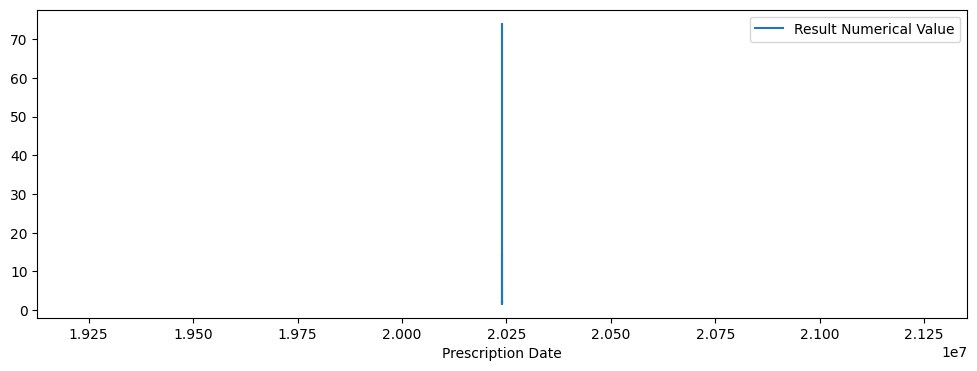

In [45]:
#plot in dft_var in x axis Prescription Date and Y axis Result Numerical Value.
fig, ax_abs = plt.subplots(figsize=(12, 4))
dft_var.plot(x="Prescription Date", y="Result Numerical Value", kind="line", ax=ax_abs)
plt.show()

In [47]:
dft_var["Result Numerical Value"]

0      2.26
17     74.0
14     1.67
11     2.26
5      1.67
20    14.36
Name: Result Numerical Value, dtype: object

In [46]:
dft_var["Prescription Date"]

0     20240329
17    20240329
14    20240329
11    20240329
5     20240329
20    20240329
Name: Prescription Date, dtype: int64